In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from statsmodels.stats.multitest import multipletests
from pygam import LinearGAM, s, f
import numpy as np
import pandas as pd
import pingouin as pg

## Funciones

In [2]:


# Función de test usando GAM en vez de RLM
def test_gam_significance(df_plot):
    df_plot['significant_gam'] = False
    p_values = []
    for (roi, band, site), subdf in df_plot.groupby(['ROI', 'Band', 'SITE']):
        if subdf['group'].nunique() < 2:
            continue
        try:
            subdf = subdf.copy()
            subdf['group_code'] = (subdf['group'] == 'MCI').astype(int)
            X = subdf[['age', 'group_code']]
            y = subdf['Value']
            gam = LinearGAM(s(0) + f(1)).fit(X, y)
            pval = gam.statistics_['p_values'][1]  # group effect
            p_values.append(((roi, band, site), pval))
            if pval < 0.05:
                df_plot.loc[
                    (df_plot['ROI'] == roi) &
                    (df_plot['Band'] == band) &
                    (df_plot['SITE'] == site), 'significant_gam'] = True
        except:
            continue
    return df_plot, dict(p_values)



In [3]:
def plot_violin_power(df_avg, bands_to_plot, save_path, title, x_legend= -2.9, y_legend=5.68):
    
    
    df_plot = df_avg[df_avg['BaseFeature'].isin(bands_to_plot)].copy()
    df_plot = df_plot.rename(columns={'BaseFeature': 'Band', 'Value': 'Power'})
    df_plot, significance_results = test_gam_significance(df_plot)

    group_palette = {'HC': 'purple', 'MCI': 'coral'}
    significance_results = {}
    df_plot['significant_gam']= False


    df_plot['ROI'] = pd.Categorical(df_plot['ROI'], categories=roi_order, ordered=True)

    # g = sns.FacetGrid(df_plot, row='Band', col='ROI', margin_titles=True,
    #                   height=4, aspect=0.8, sharex=False, sharey=False)
    g = sns.FacetGrid(df_plot, row='ROI', col='Band', margin_titles=True,
                  height=4, aspect=0.9, sharex=False, sharey=False)

    g.map_dataframe(
        sns.violinplot,
        y='SITE',
        x='Power',
        hue='group',
        split=True,
        inner=None,
        density_norm="width",
        linewidth=1.2,
        alpha=0.5,
        palette=group_palette
    )

    g.map_dataframe(
        sns.pointplot,
        y='SITE',
        x='Power',
        hue='group',
        dodge=True,
        join=False,
        markers=['o', '^'],
        palette=group_palette,
        estimator='median',
        errorbar=('ci', 95),
        err_kws={'linewidth': 1.2},
        capsize=0.2,
        scale=0.9
    )

    for (i, ax) in enumerate(g.axes.flat):
        if i >= len(g.row_names) * len(g.col_names):
            continue
        # band = g.row_names[i // len(g.col_names)]
        # roi = g.col_names[i % len(g.col_names)]
        roi = g.row_names[i // len(g.col_names)]
        band = g.col_names[i % len(g.col_names)]

        df_sub = df_plot[(df_plot['Band'] == band) & (df_plot['ROI'] == roi)]
        sig_sites = df_sub[df_sub['significant_gam']]['SITE'].unique()

        y_levels = list(df_sub['SITE'].drop_duplicates())

        for j, site in enumerate(y_levels):
            if site in sig_sites:
                ax.annotate('*', xy=(1.01, j), xycoords=('axes fraction', 'data'),
                            ha='left', va='center', fontsize=14, color='black', weight='bold')

    g.set_titles(row_template='ROI {row_name}', col_template='{col_name}',fontweight='bold')
    #plt.tight_layout(rect=[0, 0, 1, 0.9])  # Bajamos el grid un poco más

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='HC', markerfacecolor='purple', markersize=10),
        Line2D([0], [0], marker='^', color='w', label='MCI', markerfacecolor='coral', markersize=10),
        mpatches.Patch(color='none', label='* Significant difference (p < 0.05)', edgecolor='none')
    ]

    # try:
    #     g._legend.remove()
    # except AttributeError:
    #     pass

    plt.legend(
        handles=legend_elements,
        title='Group',
        loc='upper center',
        bbox_to_anchor=(x_legend, y_legend),  # ← Subo la leyenda
        ncol=3,
        frameon=False,
        fontsize=10,
        title_fontsize=12
    )

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.035)# ← Subo el título también

    plt.savefig(save_path, dpi=600, format='pdf', bbox_inches='tight', transparent=True)
    plt.show()
    return df_plot, significance_results


In [4]:
def test_gam_significance_no_site(df_plot):
    from pygam import LinearGAM, s, f

    df_plot['significant_gam'] = False
    tests = []
    for (roi, band), subdf in df_plot.groupby(['ROI', 'BaseFeature']):
        if subdf['group'].nunique() < 2:
            continue
        try:
            subdf = subdf.copy()
            subdf['group_code'] = (subdf['group'] == 'MCI').astype(int)
            X = subdf[['age', 'group_code']]
            y = subdf['Value']
            gam = LinearGAM(s(0) + f(1)).fit(X, y)
            pval = gam.statistics_['p_values'][1]
            tests.append(((roi, band), pval))
        except:
            continue

    # Corrección FDR
    keys, raw_pvals = zip(*tests)
    rejected, pvals_corrected, _, _ = multipletests(raw_pvals, method='fdr_bh')

    significance_results = {}
    for i, ((roi, band), qval) in enumerate(zip(keys, pvals_corrected)):
        significance_results[(roi, band)] = qval
        if qval < 0.05:
            df_plot.loc[
                (df_plot['ROI'] == roi) & (df_plot['BaseFeature'] == band),
                'significant_gam'
            ] = True

    return df_plot, significance_results


def plot_violin_power_no_site(df_avg, bands_to_plot, save_path, title):
    df_plot = df_avg[df_avg['BaseFeature'].isin(bands_to_plot)].copy()
    roi_order = ['F', 'C', 'P', 'O', 'PO']

    df_plot, significance_results = test_gam_significance_no_site(df_plot)
    df_plot = df_plot.rename(columns={'BaseFeature': 'Band', 'Value': 'Value'})
    df_plot['Band'] = pd.Categorical(df_plot['Band'], categories=bands_to_plot, ordered=True)
    df_plot['ROI'] = pd.Categorical(df_plot['ROI'], categories=roi_order, ordered=True)

    
    group_palette = {'HC': 'purple', 'MCI': 'coral'}

    g = sns.FacetGrid(
        df_plot, row='ROI', col='Band', margin_titles=True,
        height=3, aspect=1.0, sharex=False, sharey=False  # clave: sharex=False
    )

    g.map_dataframe(
        sns.violinplot,
        x='Value',
        y='group',
        split=True,
        inner=None,
        density_norm="width",
        linewidth=1.2,
        alpha=0.5,
        palette=group_palette
    )

    g.map_dataframe(
        sns.pointplot,
        x='Value',
        y='group',
        dodge=True,
        join=False,
        markers=['o', '^'],
        palette=group_palette,
        estimator=np.median,
        errorbar=('ci', 95),
        err_kws={'linewidth': 1.2},
        capsize=0.2,
        scale=0.9
    )

    for i, ax in enumerate(g.axes.flat):
        if i >= len(g.row_names) * len(g.col_names):
            continue

        roi = g.row_names[i // len(g.col_names)]
        band = g.col_names[i % len(g.col_names)]

        if (roi, band) in significance_results and significance_results[(roi, band)] < 0.05:
            pval = significance_results[(roi, band)]
            ax.annotate(f'*(p={pval:.3g})', xy=(0.95, 0.9), xycoords='axes fraction',
                        ha='right', va='top', fontsize=10, color='black', weight='bold')
            ax.set_facecolor('lightgrey')  # fondo gris


    g.set_titles(row_template='ROI {row_name}', col_template='{col_name}', fontweight='bold',size=12)
    g.set_axis_labels('Value', 'Group', fontsize=10)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='HC', markerfacecolor='purple', markersize=10),
        Line2D([0], [0], marker='^', color='w', label='MCI', markerfacecolor='coral', markersize=10),
        mpatches.Patch(color='lightgrey', label='* q < 0.05 (FDR-corrected GAM)')

    ]
    g.fig.legend(handles=legend_elements, title='Group', loc='lower center',
                 bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=False, fontsize=14, title_fontsize=12)

    g.fig.subplots_adjust(top=0.92, hspace=0.4, wspace=0.3)
    g.fig.suptitle(title, fontsize=16, fontweight='bold')

    plt.savefig(save_path, dpi=600, format='pdf', bbox_inches='tight', transparent=False)
    plt.show()

    return df_plot, significance_results


In [5]:
def plot_gam_significance_binary(significance_results, roi_order, bands_to_plot, save_path):
    binary_data = pd.DataFrame(index=roi_order, columns=bands_to_plot)
    text_data = pd.DataFrame(index=roi_order, columns=bands_to_plot)

    for roi in roi_order:
        for band in bands_to_plot:
            qval = significance_results.get((roi, band), 1.0)
            binary_data.loc[roi, band] = 1 if qval < 0.05 else 0
            text_data.loc[roi, band] = f"{qval:.3g}" if qval < 0.05 else ""

    binary_data = binary_data.astype(int)

    cmap = sns.color_palette(["white", "lightblue"])
    
    category_boundaries = [
    'offset',  # Parameters
    'pw_ab_beta',  # Unadjusted Ab. Power
    'pw_beta',     # Unadjusted Rel. Power
    'pw_ab_canonic_gamma',  # Ab. Canonical
    'pw_canonic_gamma',     # Rel. Canonical
    'osc_pw_ab_beta',       # Oscillatory Ab.
    'osc_pw_beta',          # Oscillatory Rel.
    'osc_pw_ab_canonic_gamma',  # Oscillatory Ab. Canonical
    'osc_pw_canonic_gamma'      # Oscillatory Rel. Canonical
    ]

    category_labels = [
        "Parameters",
        "Unadjusted Spectral\nAbsolute power",
        "Unadjusted Spectral\nRelative power",
        "Unadjusted Spectral\nAbsolute power\ncanonic bands",
        "Unadjusted Spectral\nRelative power\ncanonic bands",
        "Oscillatory spectral\nAb. power",
        "Oscillatory spectral\nRel. power",
        "Oscillatory spectral\nAb. power\ncanonic bands",
        "Oscillatory spectral\nRel. power\ncanonic bands"
    ]

    plt.figure(figsize=(16, 6))
    ax = sns.heatmap(
        binary_data,
        annot=text_data,
        fmt="",
        cmap=cmap,
        linewidths=0.5,
        linecolor='gray',
        cbar=False,
        annot_kws={"size": 7, "weight": "bold","rotation": 90,'color':"black"},
    )
    # Draw vertical lines for category boundaries
    xticks = binary_data.columns.tolist()
    for boundary in category_boundaries:
        if boundary in xticks:
            idx = xticks.index(boundary) + 1
            ax.axvline(idx, color='black', linewidth=1.5)

    # Position category labels above columns
    x_positions = []
    previous_idx = 0
    for boundary in category_boundaries:
        if boundary in xticks:
            current_idx = xticks.index(boundary)
            center = (previous_idx + current_idx) / 2
            x_positions.append(center)
            previous_idx = current_idx + 1
    final_center = (previous_idx + len(xticks) - 1) / 2
    x_positions.append(final_center)

    # Draw labels above the heatmap
    for xpos, label in zip(x_positions, category_labels):
        ax.text(xpos, -0.55, label, ha='center', va='bottom', fontsize=7)
    
    # Leyenda manual
    legend_elements = [
        mpatches.Patch(facecolor='white', edgecolor='black', label='Not significant (q ≥ 0.05)'),
        mpatches.Patch(facecolor='lightblue', edgecolor='black', label='Significant (q < 0.05)')
    ]
    ax.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 1.2), ncol=2, frameon=False, fontsize=10)

    # Styling
    plt.suptitle("GAM Significance by ROI and Feature", fontsize=13, fontweight='bold', y=1.088, x=0.5)
    plt.xlabel("Feature", fontsize=10, fontweight='bold')
    plt.ylabel("ROI", fontsize=10, fontweight='bold')
    plt.xticks(rotation=90, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=10, fontweight='bold')

    # Adjust layout for title and labels
    plt.subplots_adjust(top=0.85, bottom=0.25)
    plt.savefig(save_path, dpi=600, format='pdf', bbox_inches='tight', transparent=True)
    plt.show()

## Load data

In [6]:
path_save = r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\IAF_FOOOF_ALL_SENSORS'
IAF_FOOOF_age= pd.read_feather(rf'{path_save}\IAF_FOOOF_age.feather')

In [7]:
groups = ['HC', 'MCI']
IAF_FOOOF_age = IAF_FOOOF_age[IAF_FOOOF_age['group'].isin(groups)]

In [8]:
features = [
    # IAF & parámetros espectrales
    'IAFp', 'TF', 'CF_extalpha', 'exponent', 'offset',

  
    # Unadjusted absolute power (individual bands)
    'pw_ab_delta', 'pw_ab_theta', 'pw_ab_BGF1', 'pw_ab_BGF2', 'pw_ab_BGF3', 'pw_ab_beta',
    
    # Unadjusted relative power (individual bands)
    'pw_delta', 'pw_theta', 'pw_BGF1', 'pw_BGF2', 'pw_BGF3', 'pw_beta',


    # Unadjusted absolute power (canonical bands)
    'pw_ab_canonic_delta', 'pw_ab_canonic_theta', 'pw_ab_canonic_alpha1', 'pw_ab_canonic_alpha2',
    'pw_ab_canonic_beta1', 'pw_ab_canonic_beta2', 'pw_ab_canonic_beta3',
    'pw_ab_canonic_gamma',

    # Unadjusted relative power (canonical bands)
    'pw_canonic_delta', 'pw_canonic_theta', 'pw_canonic_alpha1', 'pw_canonic_alpha2',
    'pw_canonic_beta1', 'pw_canonic_beta2', 'pw_canonic_beta3', 'pw_canonic_gamma',
    
    # Oscillatory absolute power (individual bands)
    'osc_pw_ab_delta', 'osc_pw_ab_theta','osc_pw_ab_BGF1', 'osc_pw_ab_BGF2','osc_pw_ab_BGF3', 'osc_pw_ab_beta', 
    
    # Oscillatory relative power (individual bands)
    'osc_pw_delta','osc_pw_theta','osc_pw_BGF1','osc_pw_BGF2', 'osc_pw_BGF3',  'osc_pw_beta',

    # Oscillatory absolute power (canonical bands)
    'osc_pw_ab_canonic_delta', 'osc_pw_ab_canonic_theta', 'osc_pw_ab_canonic_alpha1','osc_pw_ab_canonic_alpha2', 'osc_pw_ab_canonic_beta1',
    'osc_pw_ab_canonic_beta2', 'osc_pw_ab_canonic_beta3','osc_pw_ab_canonic_gamma',
    
    # Oscillatory relative power (canonical bands)
    'osc_pw_canonic_delta','osc_pw_canonic_theta','osc_pw_canonic_alpha1', 'osc_pw_canonic_alpha2','osc_pw_canonic_beta1', 'osc_pw_canonic_beta2','osc_pw_canonic_beta3', 
    'osc_pw_canonic_gamma'
    
]

In [9]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D


import re

# Asegura que todos los nombres de columna son str sin espacios
IAF_FOOOF_age.columns = IAF_FOOOF_age.columns.astype(str).str.strip()

# Sensores válidos
roi_mapping = {
    'F': ['FP1', 'FP2'],
    'C': ['C3', 'C4'],
    'P': ['P7', 'P8'],
    'O': ['O1', 'O2'],
    "PO": ['P7', 'P8', 'O1', 'O2'],
}
all_sensors = sum(roi_mapping.values(), [])

# Regex: busca columnas que terminan con "_<Sensor>" exacto
pattern = re.compile(r'^(.+)_(' + '|'.join(all_sensors) + r')$')

feature_cols = [col for col in IAF_FOOOF_age.columns if pattern.match(col)]

# Melt → formato largo
df_long = IAF_FOOOF_age.melt(id_vars=['subject', 'group', 'SITE', 'age'],
                  value_vars=feature_cols,
                  var_name='Feature',
                  value_name='Value')

# Extrae Sensor y Base Feature (ej: pw_delta, IAFp, etc.)
df_long['Sensor'] = df_long['Feature'].str.extract(r'_([A-Z0-9]+)$')
df_long['BaseFeature'] = df_long['Feature'].str.extract(r'^(.+)_([A-Z0-9]+)$')[0]

# Mapear ROI desde Sensor
def map_roi(sensor):
    for roi, sensors in roi_mapping.items():
        if sensor in sensors:
            return roi
    return None

df_long['ROI'] = df_long['Sensor'].apply(map_roi)
df_long = df_long[df_long['ROI'].notnull()].copy()

# Quedarse solo con columnas que son potencia (empiezan con 'pw_')
df_pw = df_long[df_long['BaseFeature'].str.startswith('pw_')].copy()
df_avg_pw = df_pw.groupby(['subject', 'group', 'SITE', 'age', 'ROI', 'BaseFeature'])['Value'].mean().reset_index()



# Crear ROI PO como promedio de P y O
df_P = df_avg_pw[df_avg_pw['ROI'] == 'P']
df_O = df_avg_pw[df_avg_pw['ROI'] == 'O']

# Hacemos merge para que coincidan en sujeto, banda, etc.
df_PO = pd.merge(df_P, df_O, on=['subject', 'group', 'SITE', 'age', 'BaseFeature'], suffixes=('_P', '_O'))

# Promediamos los valores de P y O
df_PO['Value'] = df_PO[['Value_P', 'Value_O']].mean(axis=1)
df_PO['ROI'] = 'PO'

# Dejamos las columnas finales igual que en df_avg_pw
df_PO = df_PO[['subject', 'group', 'SITE', 'age', 'ROI', 'BaseFeature', 'Value']]

# Concatenamos al dataset original
df_avg_pw = pd.concat([df_avg_pw, df_PO], ignore_index=True)



# Definimos orden deseado de ROIs
roi_order = ['F', 'C', 'P', 'O', 'PO']



## Graphs

d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  func(*plot_args, **plot_kwargs)
d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  func(*plot_args, **plot_kwargs)
d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  func(*plot_args, **plot_kwargs)
d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: UserWarning: 

The `join` p

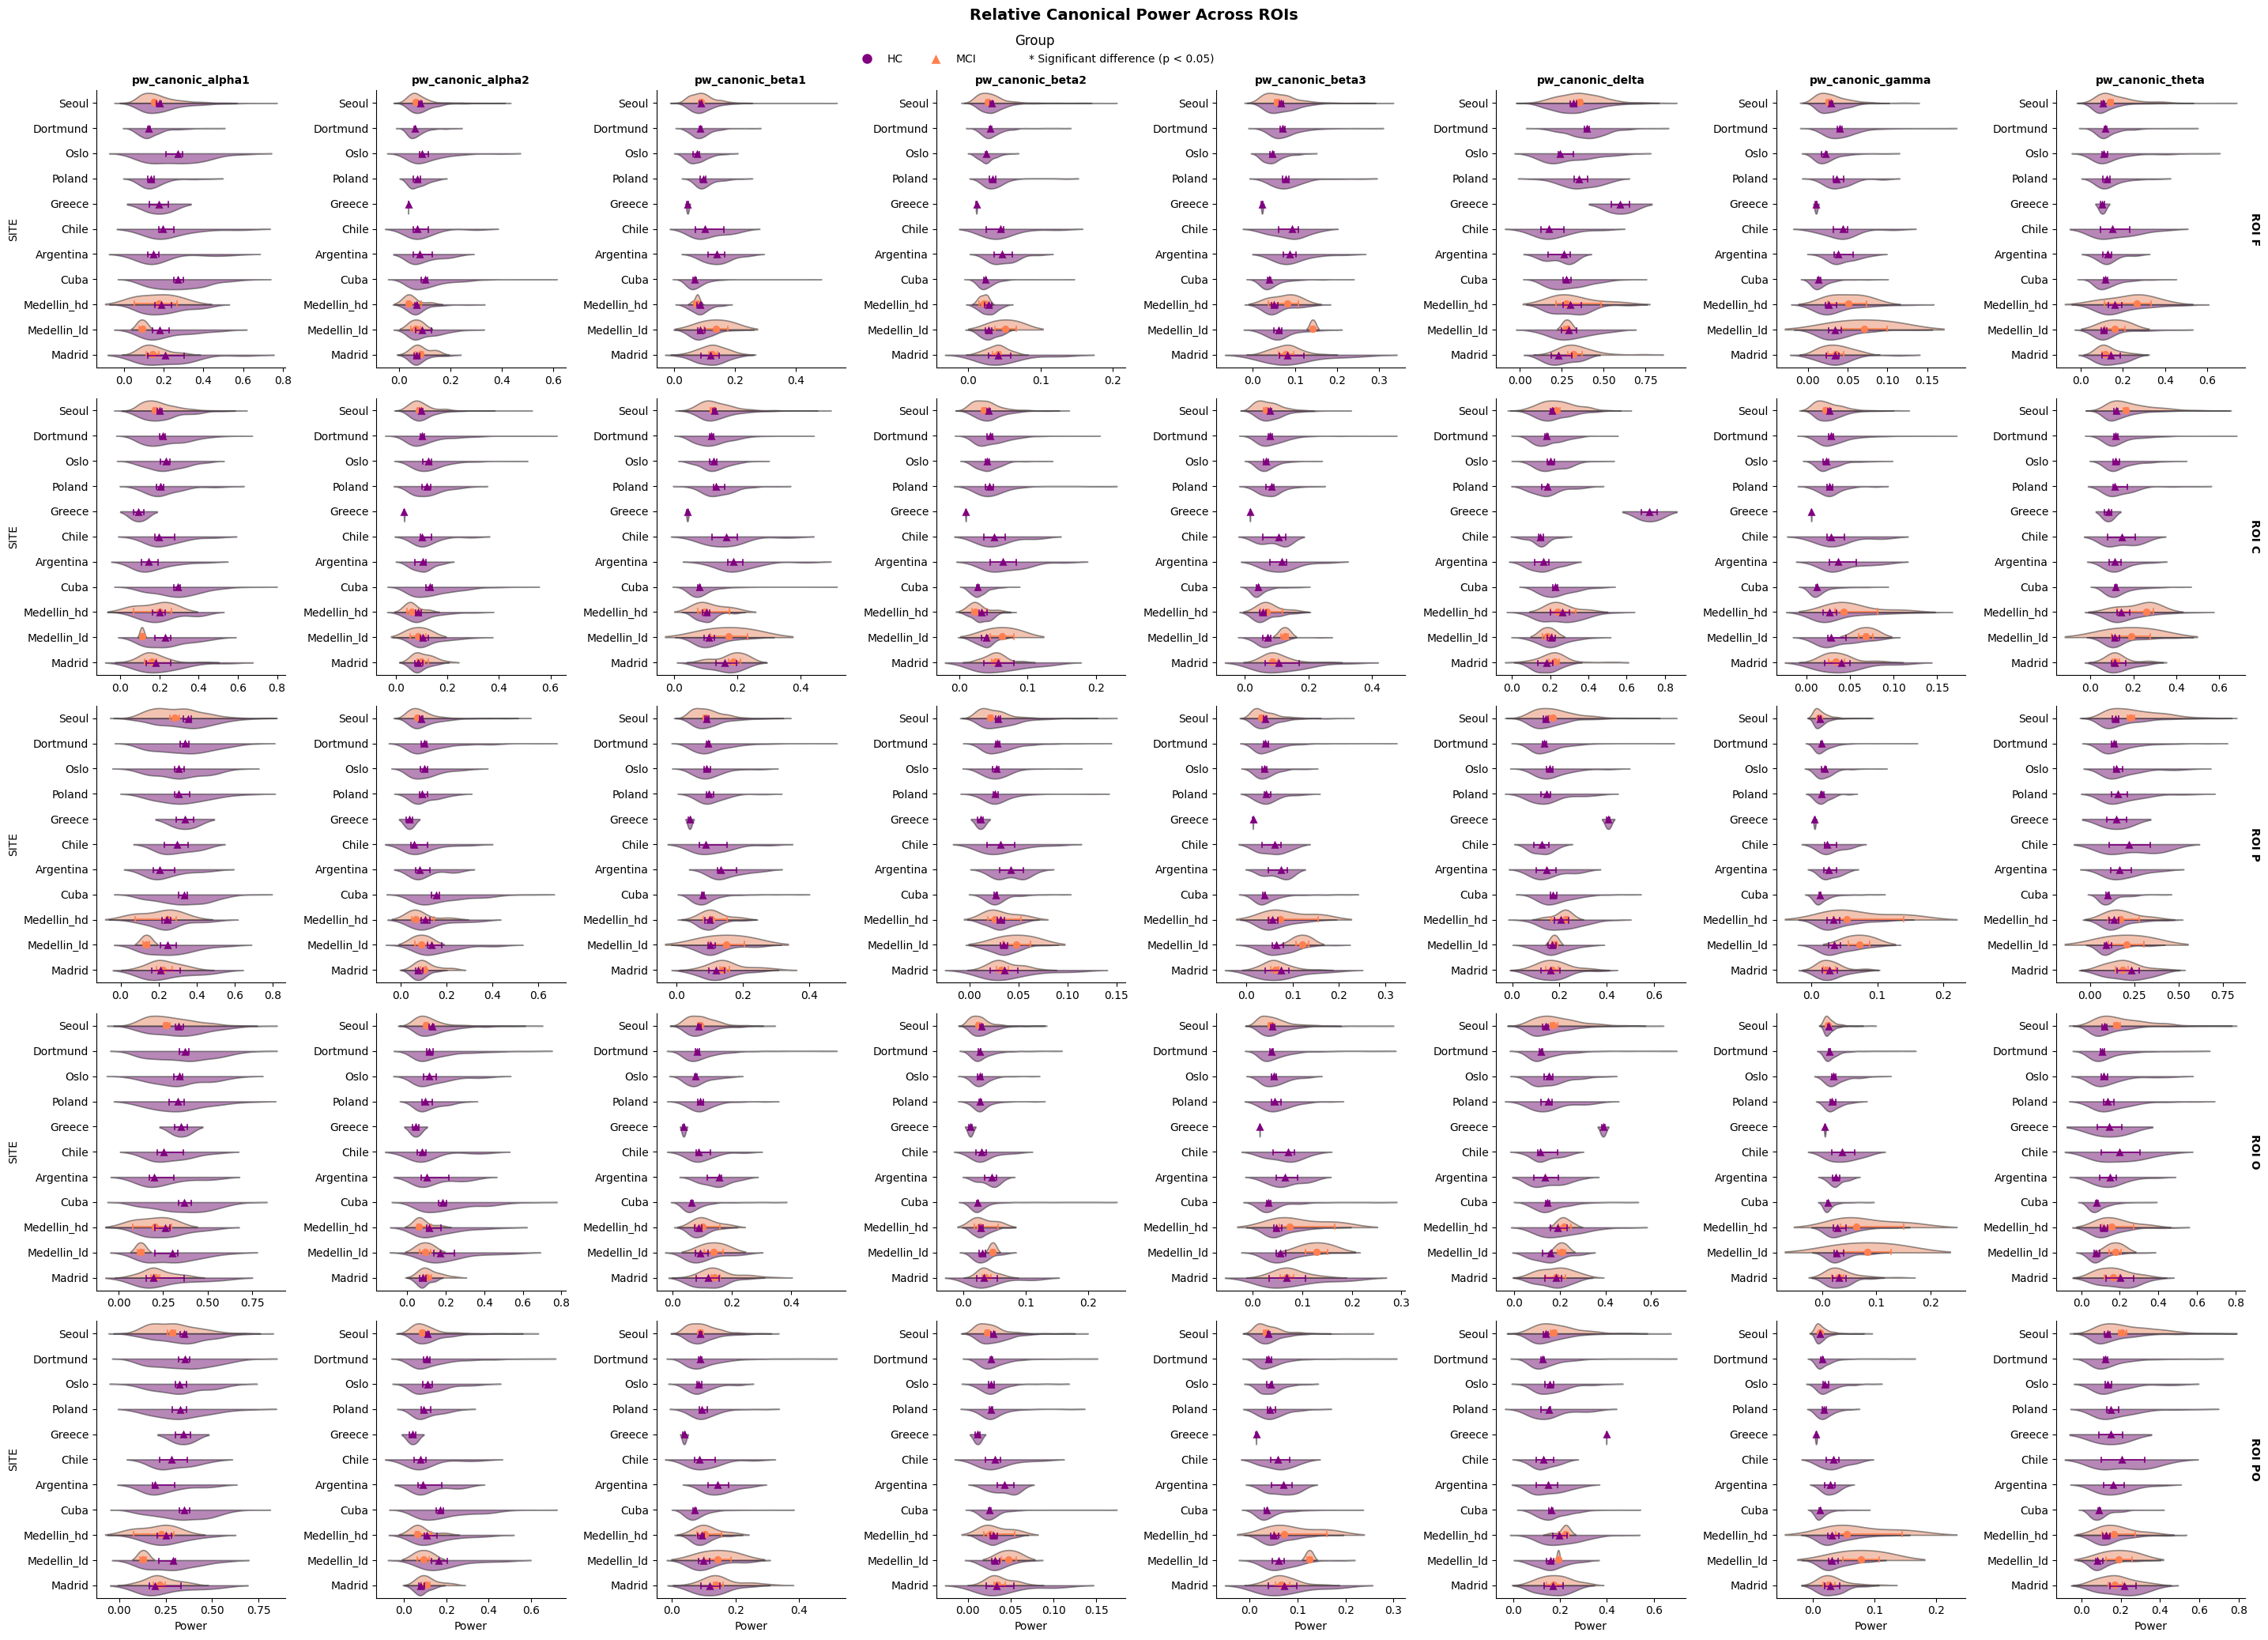

In [ ]:
plot_violin_power(
    df_avg_pw,
    bands_to_plot=['pw_delta', 'pw_theta', 'pw_BGF1', 'pw_BGF2', 'pw_BGF3', 'pw_beta'],
    save_path=r'D:\MulticentersEEG\graphs_thesis_LMZS\Power_Relative_ROI_violin_median_significance.pdf',
    title='Relative Power Across ROIs', x_legend= -3.7, y_legend=5.68
)

plot_violin_power(
    df_avg_pw,
    bands_to_plot=['pw_ab_delta', 'pw_ab_theta', 'pw_ab_BGF1', 'pw_ab_BGF2', 'pw_ab_BGF3', 'pw_ab_beta'],
    save_path=r'D:\MulticentersEEG\graphs_thesis_LMZS\Power_Absolute_ROI_violin_median_significance.pdf',
    title='Absolute Power Across ROIs',x_legend= -3.7, y_legend=5.68
)

df_plot, significance_results = plot_violin_power(
    df_avg_pw,
    bands_to_plot=[
        'pw_canonic_delta', 'pw_canonic_theta', 'pw_canonic_alpha1', 'pw_canonic_alpha2',
        'pw_canonic_beta1', 'pw_canonic_beta2', 'pw_canonic_beta3', 'pw_canonic_gamma'
    ],
    save_path=r'D:\MulticentersEEG\graphs_thesis_LMZS\Power_Relative_Canonic_ROI_violin_median_significance.pdf',
    title='Relative Canonical Power Across ROIs',x_legend= -5.4, y_legend=5.68
)


plot_violin_power(
    df_avg_pw,
    bands_to_plot=[
        'pw_ab_canonic_delta', 'pw_ab_canonic_theta', 'pw_ab_canonic_alpha1', 'pw_ab_canonic_alpha2',
        'pw_ab_canonic_beta1', 'pw_ab_canonic_beta2', 'pw_ab_canonic_beta3', 'pw_ab_canonic_gamma'
    ],
    save_path=r'D:\MulticentersEEG\graphs_thesis_LMZS\Power_Absolute_Canonic_ROI_violin_median_significance.pdf',
    title='Absolute Canonical Power Across ROIs', x_legend= -5.4, y_legend=5.68
)


In [6]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D


import re

# Asegura que todos los nombres de columna son str sin espacios
IAF_FOOOF_age.columns = IAF_FOOOF_age.columns.astype(str).str.strip()

# Sensores válidos
roi_mapping = {
    'F': ['FP1', 'FP2'],
    'C': ['C3', 'C4'],
    'P': ['P7', 'P8'],
    'O': ['O1', 'O2'],
    "PO": ['P7', 'P8', 'O1', 'O2'],
}
all_sensors = sum(roi_mapping.values(), [])

# Regex: busca columnas que terminan con "_<Sensor>" exacto
pattern = re.compile(r'^(.+)_(' + '|'.join(all_sensors) + r')$')

feature_cols = [col for col in IAF_FOOOF_age.columns if pattern.match(col)]

# Melt → formato largo
df_long = IAF_FOOOF_age.melt(id_vars=['subject', 'group', 'SITE', 'age'],
                  value_vars=feature_cols,
                  var_name='Feature',
                  value_name='Value')

# Extrae Sensor y Base Feature (ej: pw_delta, IAFp, etc.)
df_long['Sensor'] = df_long['Feature'].str.extract(r'_([A-Z0-9]+)$')
df_long['BaseFeature'] = df_long['Feature'].str.extract(r'^(.+)_([A-Z0-9]+)$')[0]

# Mapear ROI desde Sensor
def map_roi(sensor):
    for roi, sensors in roi_mapping.items():
        if sensor in sensors:
            return roi
    return None

df_long['ROI'] = df_long['Sensor'].apply(map_roi)
df_long = df_long[df_long['ROI'].notnull()].copy()

# Quedarse solo con columnas que son potencia (empiezan con 'pw_')
#df_pw = df_long[df_long['BaseFeature'].str.startswith('pw_')].copy()
df_pw = df_long[df_long['BaseFeature'].str.match(r'^(pw_|IAFp|TF|CF_extalpha|exponent|offset|osc_)')].copy()

df_avg_pw = df_pw.groupby(['subject', 'group', 'SITE', 'age', 'ROI', 'BaseFeature'])['Value'].mean().reset_index()



# Crear ROI PO como promedio de P y O
df_P = df_avg_pw[df_avg_pw['ROI'] == 'P']
df_O = df_avg_pw[df_avg_pw['ROI'] == 'O']

# Hacemos merge para que coincidan en sujeto, banda, etc.
df_PO = pd.merge(df_P, df_O, on=['subject', 'group', 'SITE', 'age', 'BaseFeature'], suffixes=('_P', '_O'))

# Promediamos los valores de P y O
df_PO['Value'] = df_PO[['Value_P', 'Value_O']].mean(axis=1)
df_PO['ROI'] = 'PO'

# Dejamos las columnas finales igual que en df_avg_pw
df_PO = df_PO[['subject', 'group', 'SITE', 'age', 'ROI', 'BaseFeature', 'Value']]

# Concatenamos al dataset original
df_avg_pw = pd.concat([df_avg_pw, df_PO], ignore_index=True)



d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assign

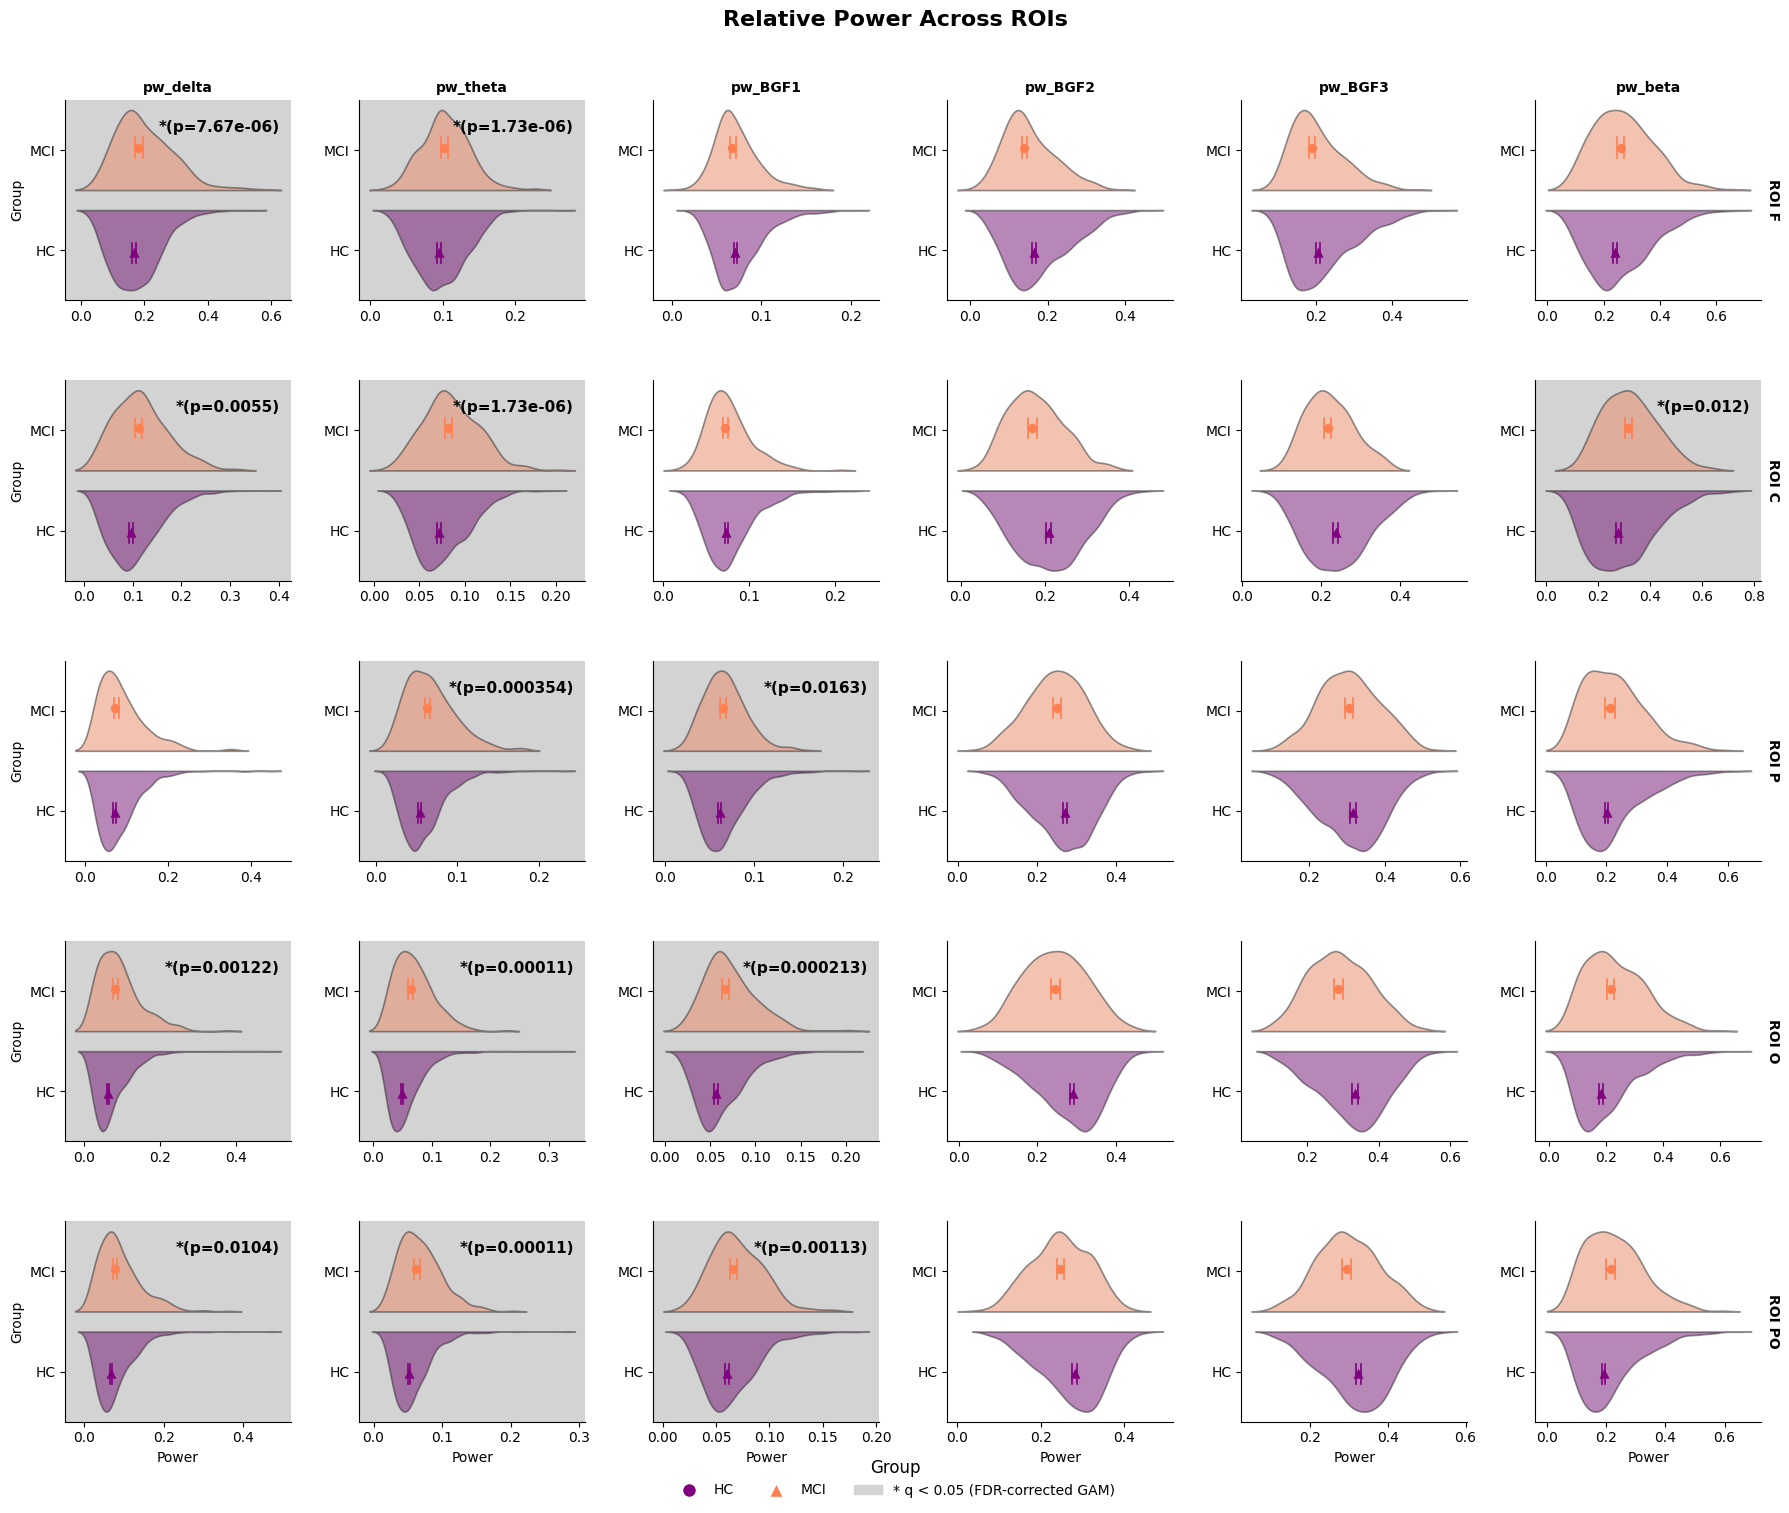

d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assign

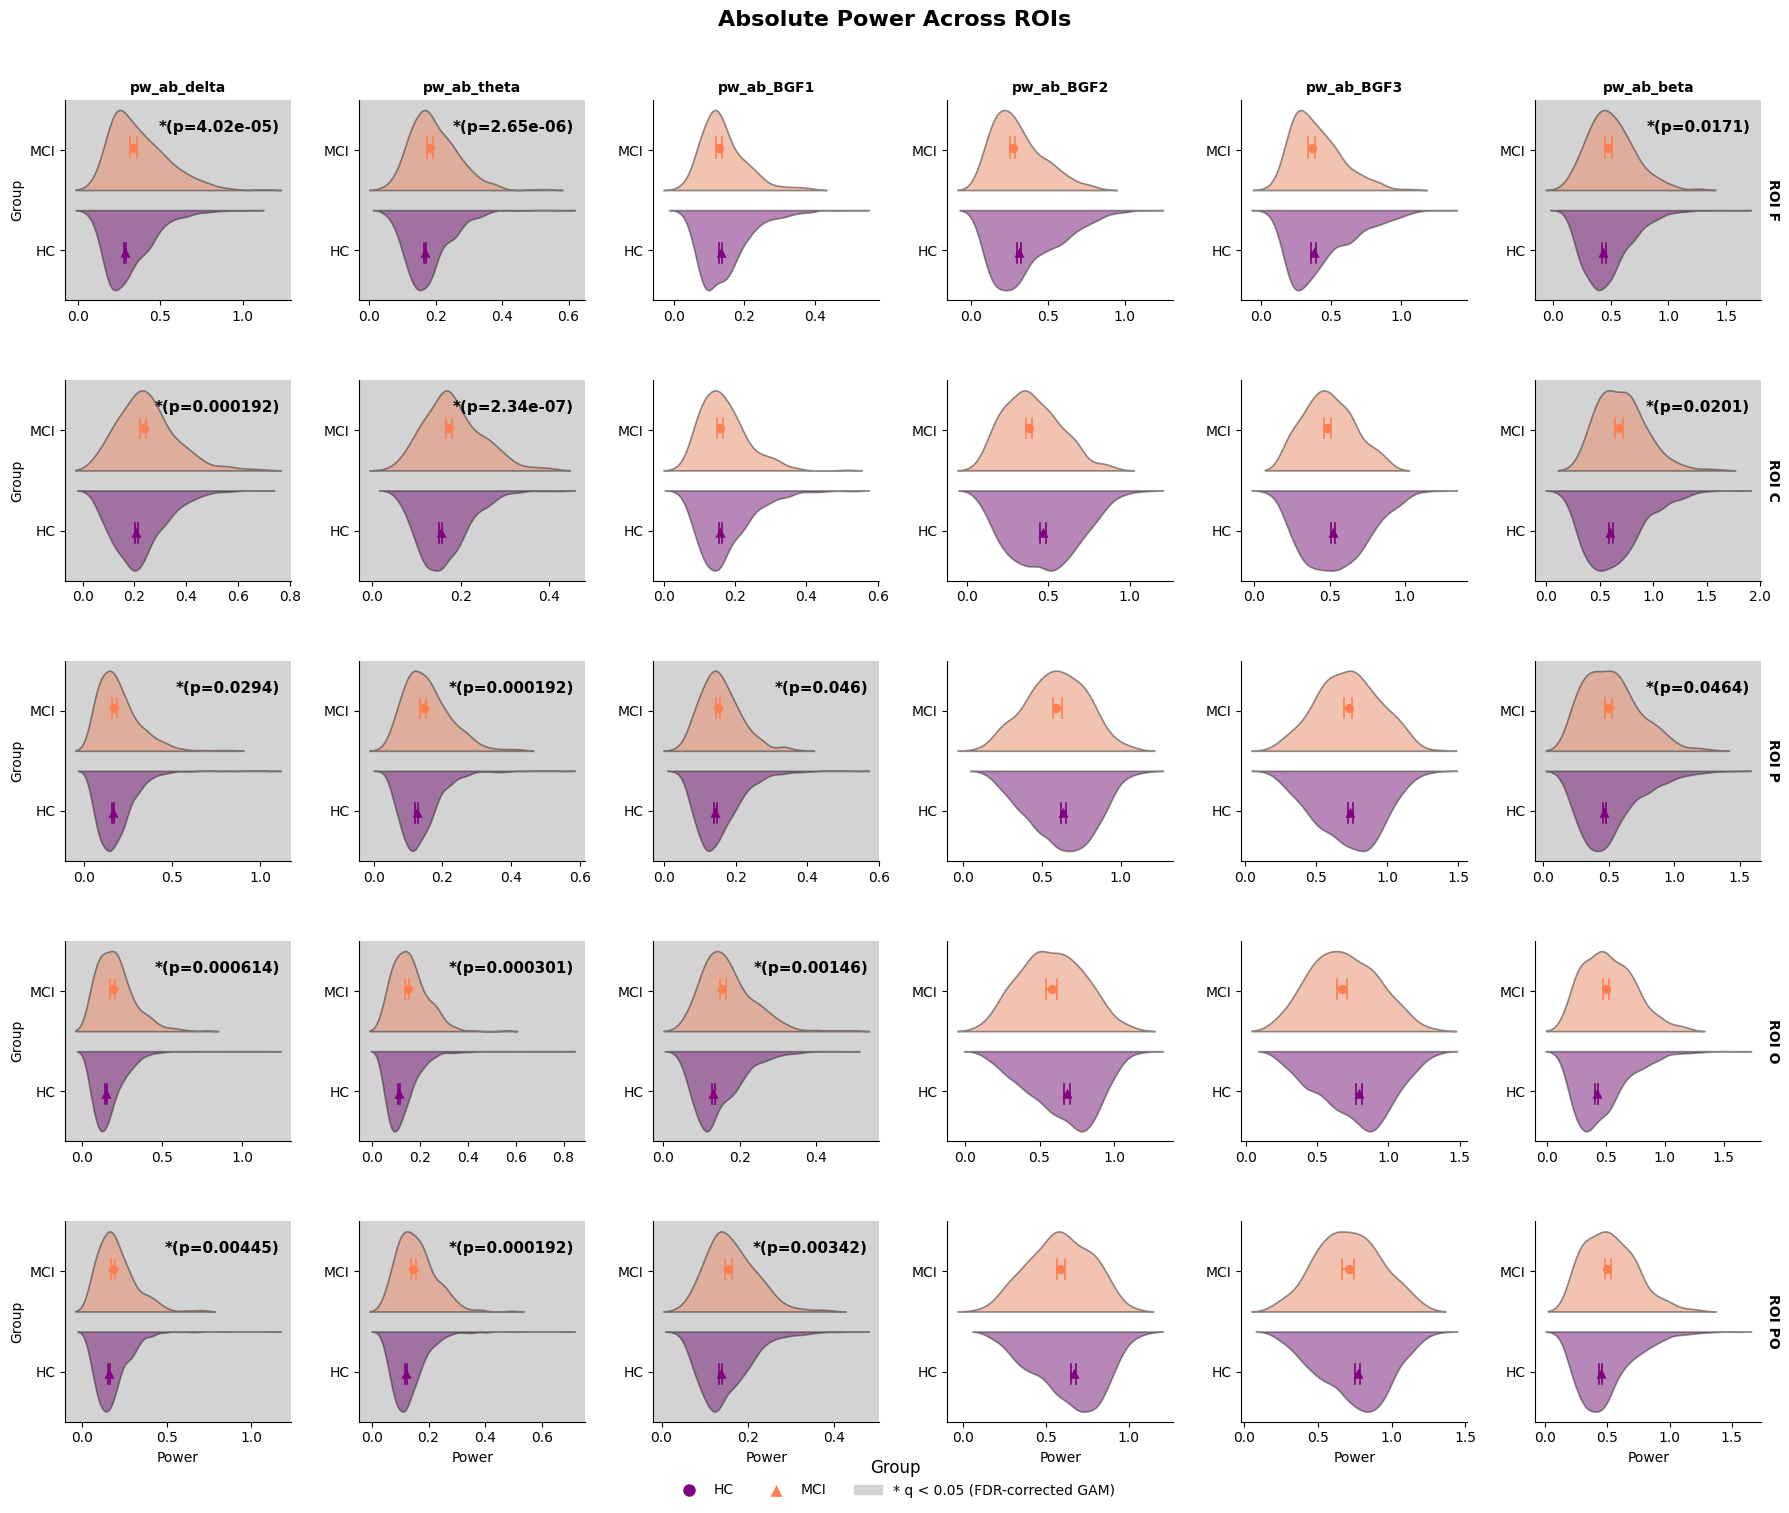

d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assign

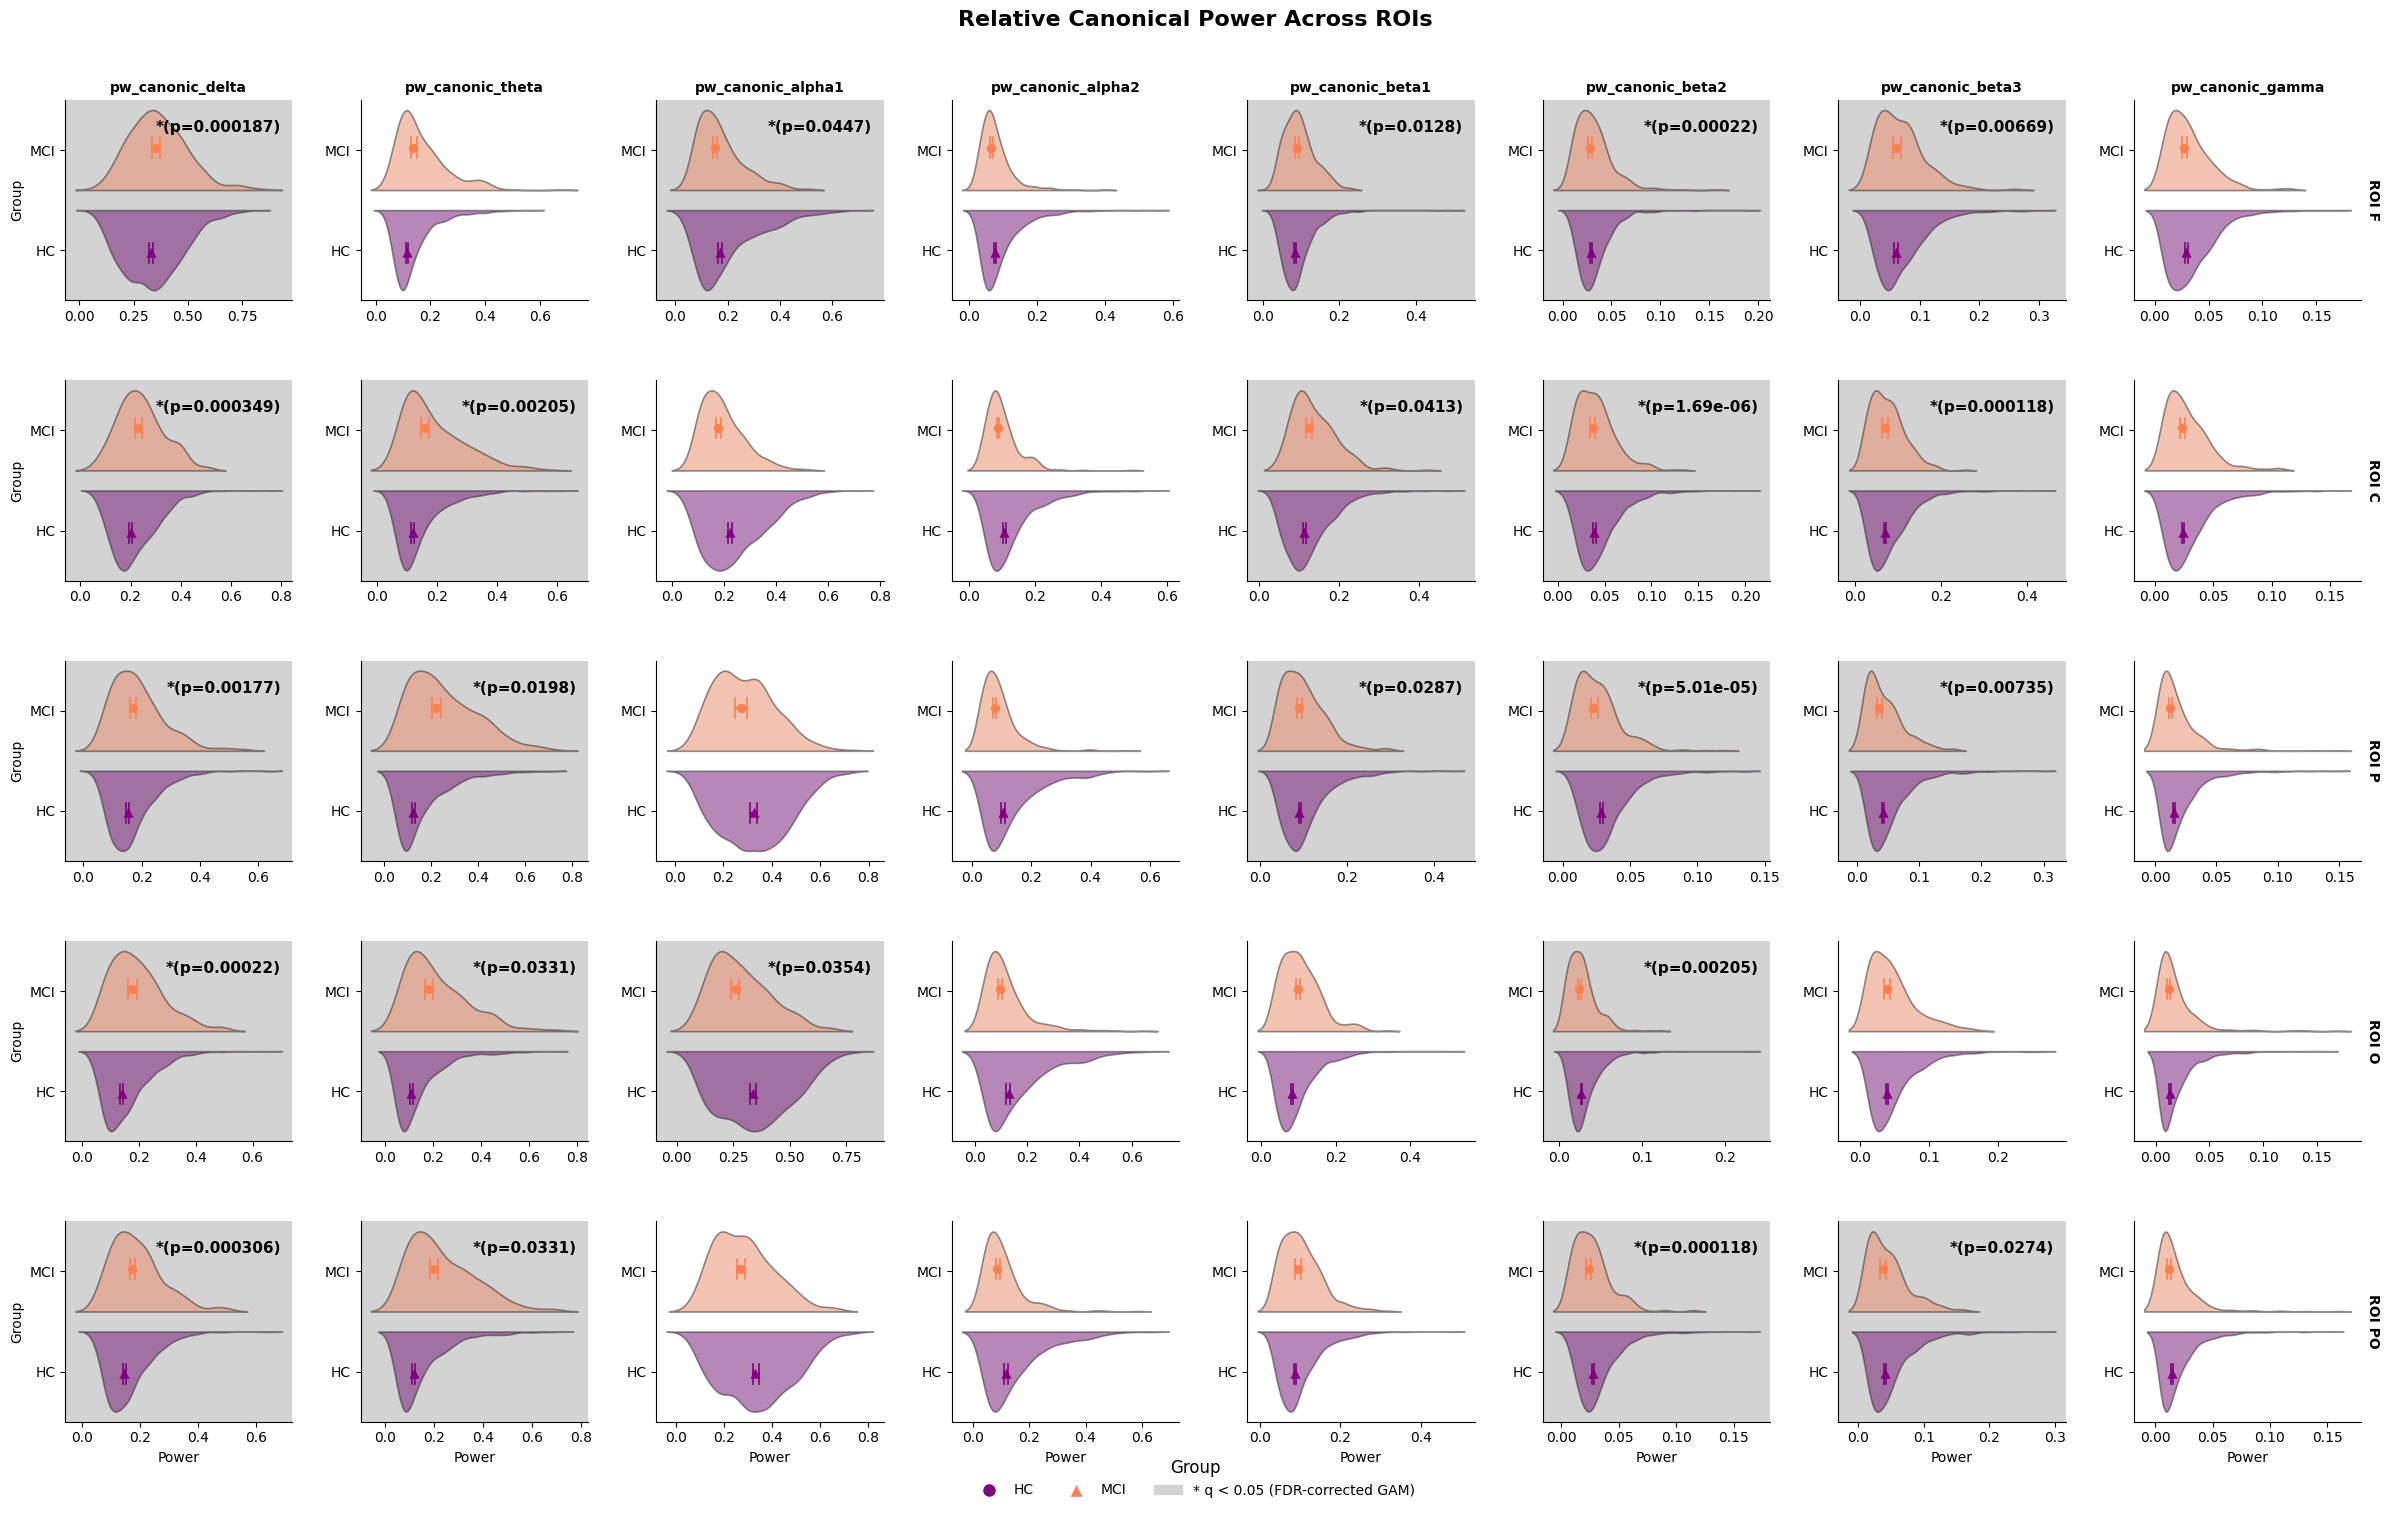

d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
d:\flujo_portables\env_recombat\lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assign

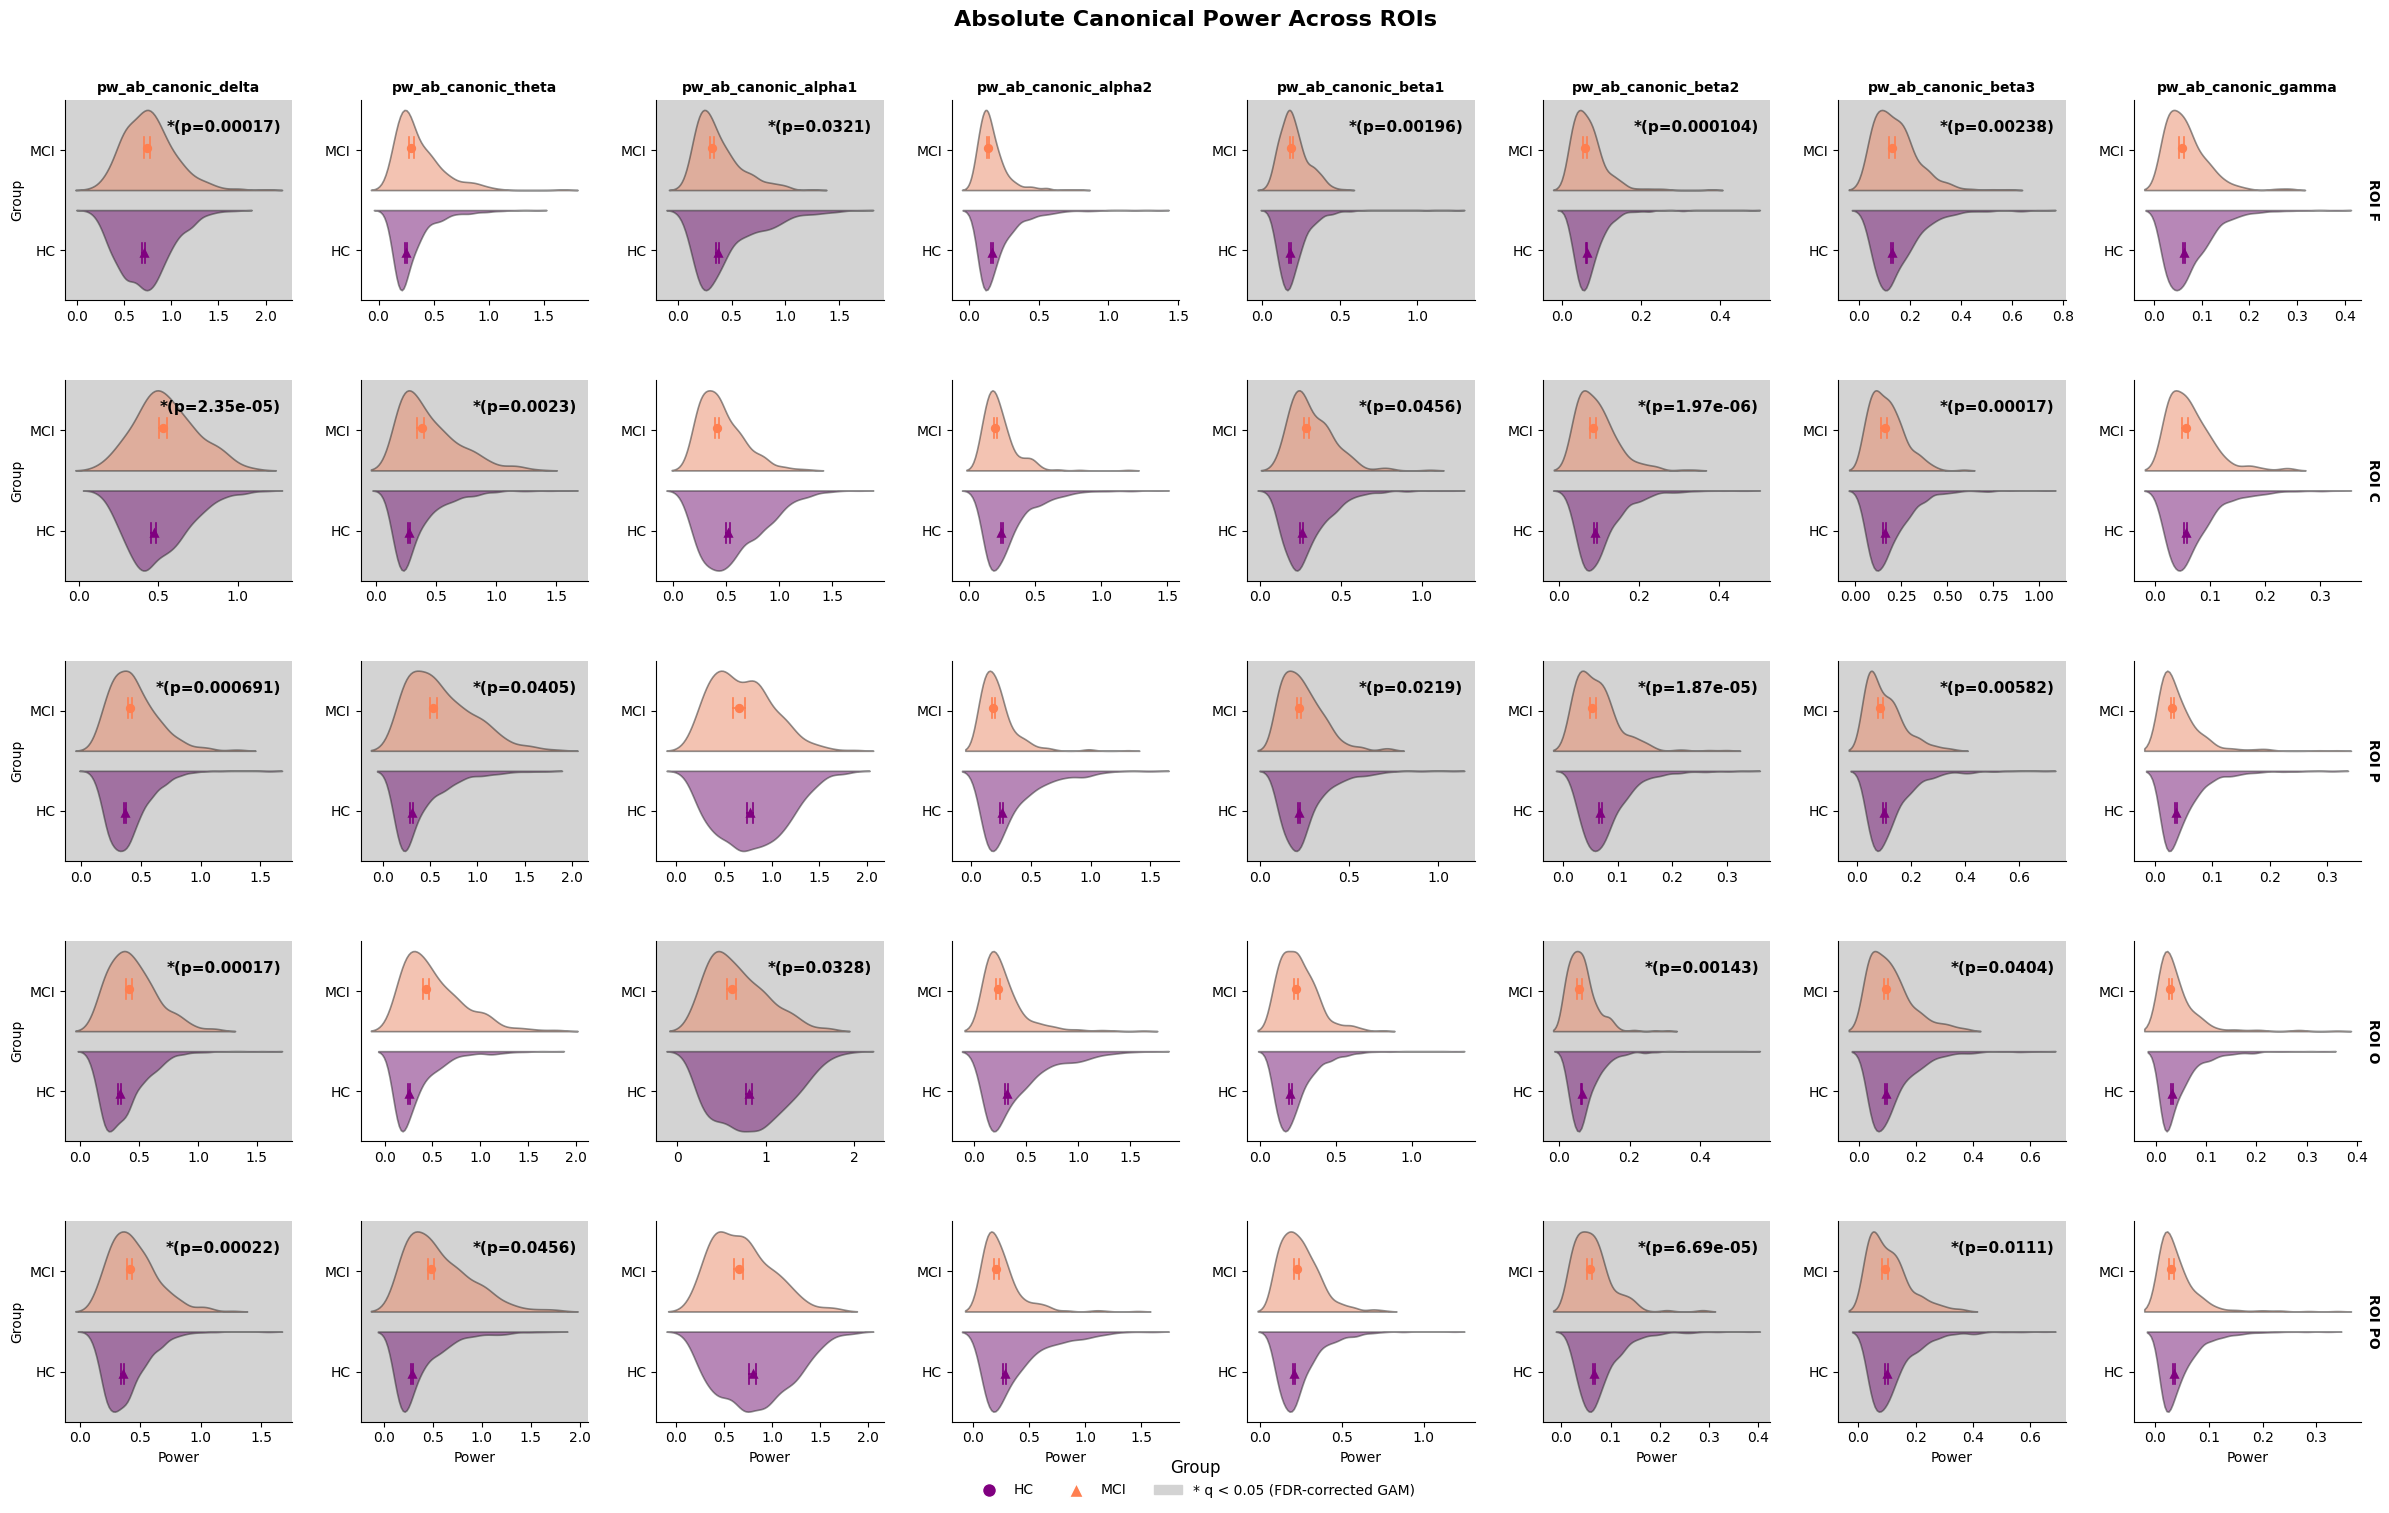

(          subject group         SITE   age ROI                  Band  \
 7       sub-00001   MCI        Seoul  78.0   C  pw_ab_canonic_alpha1   
 8       sub-00001   MCI        Seoul  78.0   C  pw_ab_canonic_alpha2   
 9       sub-00001   MCI        Seoul  78.0   C   pw_ab_canonic_beta1   
 10      sub-00001   MCI        Seoul  78.0   C   pw_ab_canonic_beta2   
 11      sub-00001   MCI        Seoul  78.0   C   pw_ab_canonic_beta3   
 ...           ...   ...          ...   ...  ..                   ...   
 216422  sub-GU082    HC  Medellin_ld  26.0  PO   pw_ab_canonic_beta2   
 216423  sub-GU082    HC  Medellin_ld  26.0  PO   pw_ab_canonic_beta3   
 216424  sub-GU082    HC  Medellin_ld  26.0  PO   pw_ab_canonic_delta   
 216425  sub-GU082    HC  Medellin_ld  26.0  PO   pw_ab_canonic_gamma   
 216426  sub-GU082    HC  Medellin_ld  26.0  PO   pw_ab_canonic_theta   
 
            Power  significant_gam  
 7       0.263328            False  
 8       0.177577            False  
 9       0.

In [ ]:
plot_violin_power_no_site(
    df_avg_pw,
    bands_to_plot=['IAFp','TF','CF_extalpha','exponent', 'offset'],
    save_path=r'D:\MulticentersEEG\graphs_thesis_LMZS\IAFp_ROI_violin_median_significance.pdf',
    title='Parameters Variability across ROIs'
)

plot_violin_power_no_site(
    df_avg_pw,
    bands_to_plot=['pw_delta', 'pw_theta', 'pw_BGF1', 'pw_BGF2', 'pw_BGF3', 'pw_beta'],
    save_path=r'D:\MulticentersEEG\graphs_thesis_LMZS\Power_Relative_ROI_violin_median_significance.pdf',
    title='Unadjusted Relative Power Across ROIs'
)

plot_violin_power_no_site(
    df_avg_pw,
    bands_to_plot=['pw_ab_delta', 'pw_ab_theta', 'pw_ab_BGF1', 'pw_ab_BGF2', 'pw_ab_BGF3', 'pw_ab_beta'],
    save_path=r'D:\MulticentersEEG\graphs_thesis_LMZS\Power_Absolute_ROI_violin_median_significance.pdf',
    title='Unadjusted Absolute Power Across ROIs')

df_plot, significance_results = plot_violin_power_no_site(
    df_avg_pw,
    bands_to_plot=[
        'pw_canonic_delta', 'pw_canonic_theta', 'pw_canonic_alpha1', 'pw_canonic_alpha2',
        'pw_canonic_beta1', 'pw_canonic_beta2', 'pw_canonic_beta3', 'pw_canonic_gamma'
    ],
    save_path=r'D:\MulticentersEEG\graphs_thesis_LMZS\Power_Relative_Canonic_ROI_violin_median_significance.pdf',
    title='Unadjusted Relative Canonical Power Across ROIs')


plot_violin_power_no_site(
    df_avg_pw,
    bands_to_plot=[
        'pw_ab_canonic_delta', 'pw_ab_canonic_theta', 'pw_ab_canonic_alpha1', 'pw_ab_canonic_alpha2',
        'pw_ab_canonic_beta1', 'pw_ab_canonic_beta2', 'pw_ab_canonic_beta3', 'pw_ab_canonic_gamma'
    ],
    save_path=r'D:\MulticentersEEG\graphs_thesis_LMZS\Power_Absolute_Canonic_ROI_violin_median_significance.pdf',
    title='Unadjusted Absolute Canonical Power Across ROIs'
)

plot_violin_power_no_site(
    df_avg_pw,
    bands_to_plot=['osc_pw_delta', 'osc_pw_theta', 'osc_pw_BGF1', 'osc_pw_BGF2', 'osc_pw_BGF3', 'osc_pw_beta'],
    save_path=r'D:\MulticentersEEG\graphs_thesis_LMZS\OSC_Power_Relative_ROI_violin_median_significance.pdf',
    title='Oscillatory Relative Power Across ROIs'
)

plot_violin_power_no_site(
    df_avg_pw,
    bands_to_plot=['osc_pw_ab_delta', 'osc_pw_ab_theta', 'osc_pw_ab_BGF1', 'osc_pw_ab_BGF2', 'osc_pw_ab_BGF3', 'osc_pw_ab_beta'],
    save_path=r'D:\MulticentersEEG\graphs_thesis_LMZS\OSC_Power_Absolute_ROI_violin_median_significance.pdf',
    title='Oscillatory Absolute Power Across ROIs')

df_plot, significance_results = plot_violin_power_no_site(
    df_avg_pw,
    bands_to_plot=[
        'osc_pw_canonic_delta', 'osc_pw_canonic_theta', 'osc_pw_canonic_alpha1', 'osc_pw_canonic_alpha2',
        'osc_pw_canonic_beta1', 'osc_pw_canonic_beta2', 'osc_pw_canonic_beta3', 'osc_pw_canonic_gamma'
    ],
    save_path=r'D:\MulticentersEEG\graphs_thesis_LMZS\OSC_Power_Relative_Canonic_ROI_violin_median_significance.pdf',
    title='Oscillatory Relative Canonical Power Across ROIs')


plot_violin_power_no_site(
    df_avg_pw,
    bands_to_plot=[
        'osc_pw_ab_canonic_delta', 'osc_pw_ab_canonic_theta', 'osc_pw_ab_canonic_alpha1', 'osc_pw_ab_canonic_alpha2',
        'osc_pw_ab_canonic_beta1', 'osc_pw_ab_canonic_beta2', 'osc_pw_ab_canonic_beta3', 'osc_pw_ab_canonic_gamma'
    ],
    save_path=r'D:\MulticentersEEG\graphs_thesis_LMZS\OSC_Power_Absolute_Canonic_ROI_violin_median_significance.pdf',
    title='Oscillatory Absolute Canonical Power Across ROIs'
)


## GAM heatmap

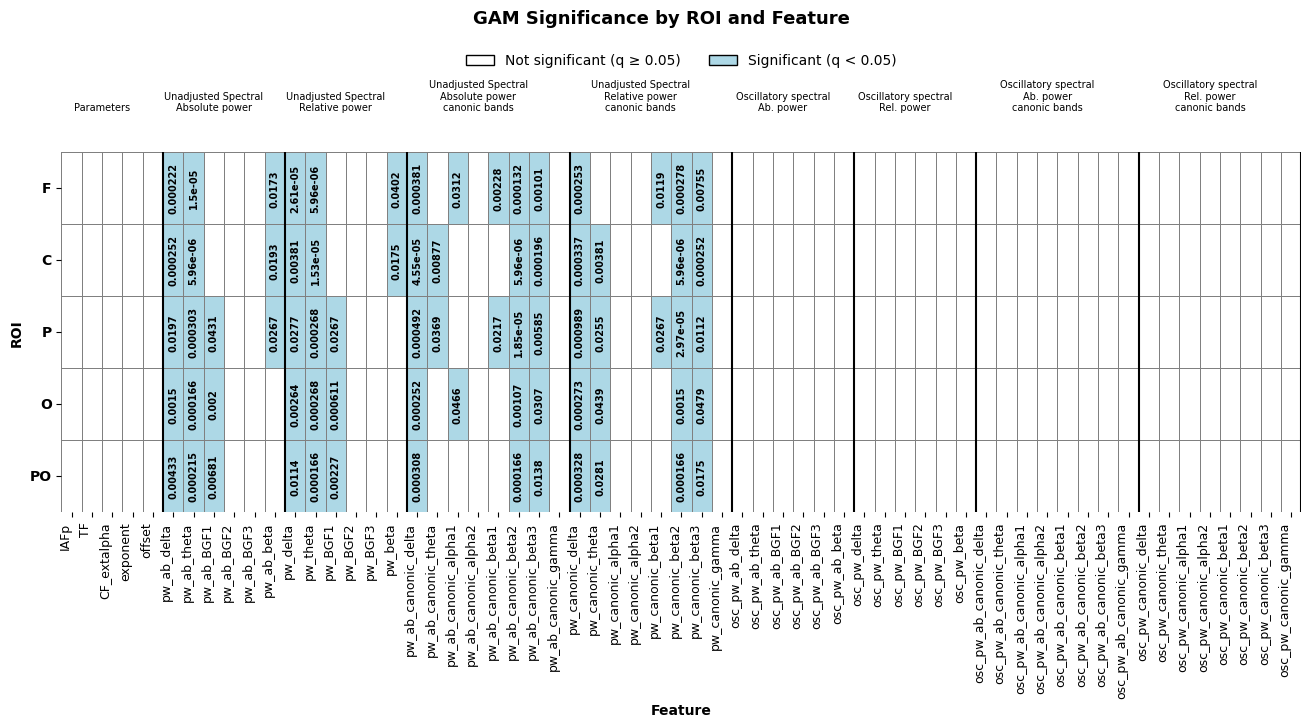

In [10]:
df_plot, significance_results = test_gam_significance_no_site(df_avg_pw)

plot_gam_significance_binary(significance_results, roi_order=['F','C','P','O','PO'], bands_to_plot=features, save_path=r'D:\MulticentersEEG\graphs_thesis_LMZS\GAM_significance_binary.pdf')


## Cohen heatmap

In [11]:


results = []

# Asegúrate de limpiar espacios extra
df_avg_pw['group'] = df_avg_pw['group'].str.strip()
df_avg_pw['Value'] = pd.to_numeric(df_avg_pw['Value'], errors='coerce')

# Iterar por cada combinación de BaseFeature y ROI
for feature in df_avg_pw['BaseFeature'].unique():
    for roi in df_avg_pw['ROI'].unique():
        subset = df_avg_pw[(df_avg_pw['BaseFeature'] == feature) & (df_avg_pw['ROI'] == roi)]

        # Verificar que haya datos para ambos grupos
        if subset['group'].nunique() == 2:
            hc_values = subset[subset['group'] == 'HC']['Value']
            mci_values = subset[subset['group'] == 'MCI']['Value']

            # Asegurar tamaño suficiente y desviación no nula
            if len(hc_values) > 1 and len(mci_values) > 1:
                std_hc, std_mci = hc_values.std(), mci_values.std()
                if std_hc > 0 and std_mci > 0:
                    try:
                        d = pg.compute_effsize(hc_values.to_numpy(), mci_values.to_numpy(), eftype='cohen')
                        if not np.isnan(d):
                            results.append({'BaseFeature': feature, 'ROI': roi, 'Cohen_d': abs(d)})
                    except Exception as e:
                        print(f"❌ Error in {feature}-{roi}: {e}")


In [12]:
# Convertir resultados a DataFrame
df_cohen = pd.DataFrame(results)

df_cohen = df_cohen[df_cohen['BaseFeature'].isin(features)].copy()
df_cohen['BaseFeature'] = pd.Categorical(df_cohen['BaseFeature'], categories=features, ordered=True)

# Pivotear para formato matriz: filas = ROI, columnas = BaseFeature
heatmap_data = df_cohen.pivot(index='ROI', columns='BaseFeature', values='Cohen_d')




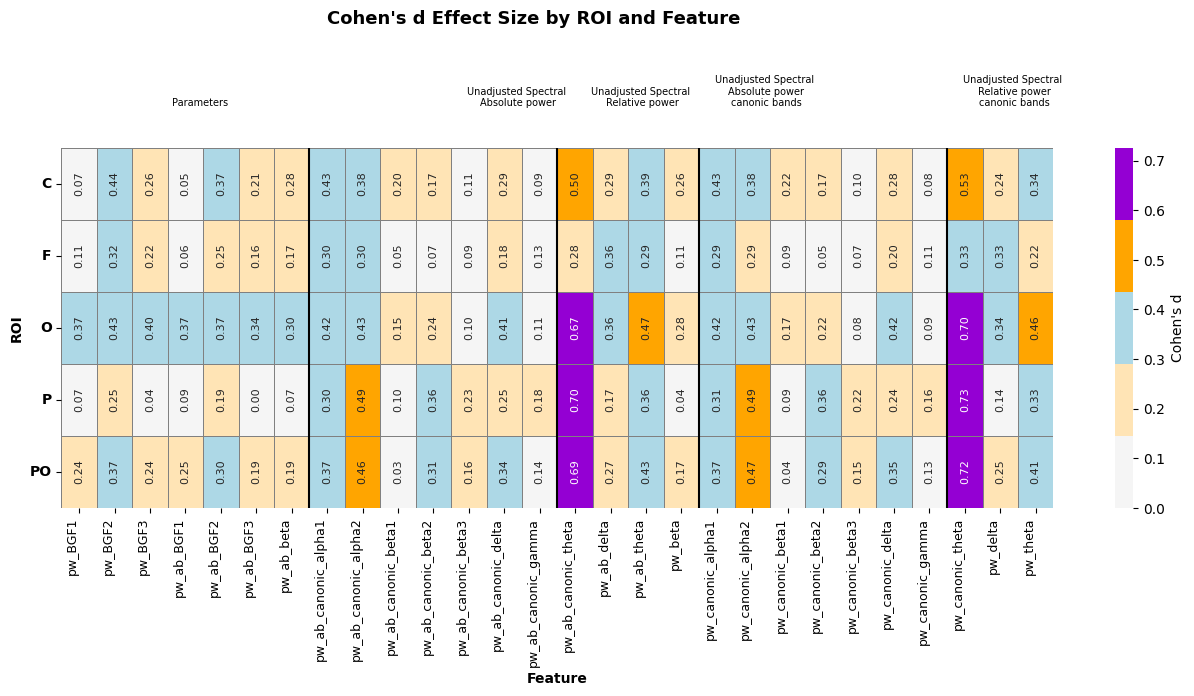

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define color bins based on effect size interpretation
bounds = [0, 0.2, 0.5, 0.8, 1.3, df_cohen['Cohen_d'].max()]
colors = ["whitesmoke", "moccasin", "lightblue", "orange", "darkviolet"]
cmap = sns.color_palette(colors)

# Define feature category boundaries for visual separation
category_boundaries = [
    'offset',  # Parameters
    'pw_ab_beta',  # Unadjusted Ab. Power
    'pw_beta',     # Unadjusted Rel. Power
    'pw_ab_canonic_gamma',  # Ab. Canonical
    'pw_canonic_gamma',     # Rel. Canonical
    'osc_pw_ab_beta',       # Oscillatory Ab.
    'osc_pw_beta',          # Oscillatory Rel.
    'osc_pw_ab_canonic_gamma',  # Oscillatory Ab. Canonical
    'osc_pw_canonic_gamma'      # Oscillatory Rel. Canonical
]

category_labels = [
    "Parameters",
    "Unadjusted Spectral \nAbsolute power",
    "Unadjusted Spectral \nRelative power",
    "Unadjusted Spectral \nAbsolute power\ncanonic bands",
    "Unadjusted Spectral \nRelative power\ncanonic bands",
    "Oscillatory spectral\nAb. power",
    "Oscillatory spectral\nRel. power",
    "Oscillatory spectral\nAb. power\ncanonic bands",
    "Oscillatory spectral\nRel. power\ncanonic bands"
]

# Create figure
plt.figure(figsize=(16, 6))  # landscape layout
ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    annot_kws={"size": 8,"rotation": 90},
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': "Cohen's d"},
    vmin=0,
    vmax=bounds[-1]
)

# Draw vertical lines for category boundaries
xticks = heatmap_data.columns.tolist()
for boundary in category_boundaries:
    if boundary in xticks:
        idx = xticks.index(boundary) + 1
        ax.axvline(idx, color='black', linewidth=1.5)

# Position category labels above columns
x_positions = []
previous_idx = 0
for boundary in category_boundaries:
    if boundary in xticks:
        current_idx = xticks.index(boundary)
        center = (previous_idx + current_idx) / 2
        x_positions.append(center)
        previous_idx = current_idx + 1
final_center = (previous_idx + len(xticks) - 1) / 2
x_positions.append(final_center)

# Draw labels above the heatmap
for xpos, label in zip(x_positions, category_labels):
    ax.text(xpos+0.9, -0.55, label, ha='center', va='bottom', fontsize=7)

# Styling
plt.suptitle("Cohen's d Effect Size by ROI and Feature", fontsize=13, fontweight='bold', y=1.08, x=0.42)
plt.xlabel("Feature", fontsize=10, fontweight='bold')
plt.ylabel("ROI", fontsize=10, fontweight='bold')
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=10, fontweight='bold')

# Adjust layout for title and labels
plt.subplots_adjust(top=0.85, bottom=0.25)

# Export as high-quality PDF
plt.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\Cohen_d_heatmap_horizontal.pdf',
            dpi=600, format='pdf', bbox_inches='tight', transparent=True)
plt.show()


## Alnternative pipeline

In [15]:
path_save = r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\features_alternative_pipeline\AIF_Babiloni\IAF_FOOOF_ALL_SENSORS'
IAF_FOOOF_age_p1= pd.read_feather(rf'{path_save}\IAF_FOOOF_age.feather')
path_save = r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni\IAF_FOOOF_ALL_SENSORS'
IAF_FOOOF_age_p2= pd.read_feather(rf'{path_save}\IAF_FOOOF_age.feather')

In [16]:
# Reutiliza tu código de procesamiento para ambos pipelines
def prepare_df_cohen(IAF_FOOOF_age_raw, disease_groups):
    import re
    roi_mapping = {
        'F': ['FP1', 'FP2'],
        'C': ['C3', 'C4'],
        'P': ['P7', 'P8'],
        'O': ['O1', 'O2'],
        "PO": ['P7', 'P8', 'O1', 'O2'],
    }
    all_sensors = sum(roi_mapping.values(), [])
    pattern = re.compile(r'^(.+)_(' + '|'.join(all_sensors) + r')$')

    IAF_FOOOF_age_raw.columns = IAF_FOOOF_age_raw.columns.astype(str).str.strip()
    IAF_FOOOF_age = IAF_FOOOF_age_raw[IAF_FOOOF_age_raw['group'].isin(['HC', disease_groups])].copy()
    feature_cols = [col for col in IAF_FOOOF_age.columns if pattern.match(col)]

    df_long = IAF_FOOOF_age.melt(id_vars=['subject', 'group', 'SITE', 'age'],
                      value_vars=feature_cols,
                      var_name='Feature',
                      value_name='Value')

    df_long['Sensor'] = df_long['Feature'].str.extract(r'_([A-Z0-9]+)$')
    df_long['BaseFeature'] = df_long['Feature'].str.extract(r'^(.+)_([A-Z0-9]+)$')[0]

    def map_roi(sensor):
        for roi, sensors in roi_mapping.items():
            if sensor in sensors:
                return roi
        return None

    df_long['ROI'] = df_long['Sensor'].apply(map_roi)
    df_long = df_long[df_long['ROI'].notnull()].copy()

    df_pw = df_long[df_long['BaseFeature'].str.match(r'^(pw_|IAFp|TF|CF_extalpha|exponent|offset|osc_)')].copy()
    df_avg_pw = df_pw.groupby(['subject', 'group', 'SITE', 'age', 'ROI', 'BaseFeature'])['Value'].mean().reset_index()

    # ROI PO
    df_P = df_avg_pw[df_avg_pw['ROI'] == 'P']
    df_O = df_avg_pw[df_avg_pw['ROI'] == 'O']
    df_PO = pd.merge(df_P, df_O, on=['subject', 'group', 'SITE', 'age', 'BaseFeature'], suffixes=('_P', '_O'))
    df_PO['Value'] = df_PO[['Value_P', 'Value_O']].mean(axis=1)
    df_PO['ROI'] = 'PO'
    df_PO = df_PO[['subject', 'group', 'SITE', 'age', 'ROI', 'BaseFeature', 'Value']]
    df_avg_pw = pd.concat([df_avg_pw, df_PO], ignore_index=True)

    df_avg_pw['group'] = df_avg_pw['group'].str.strip()
    df_avg_pw['Value'] = pd.to_numeric(df_avg_pw['Value'], errors='coerce')

    results = []
    for feature in df_avg_pw['BaseFeature'].unique():
        for roi in df_avg_pw['ROI'].unique():
            subset = df_avg_pw[(df_avg_pw['BaseFeature'] == feature) & (df_avg_pw['ROI'] == roi)]
            if subset['group'].nunique() == 2:
                hc_values = subset[subset['group'] == 'HC']['Value']
                mci_values = subset[subset['group'] == disease_groups]['Value']
                if len(hc_values) > 1 and len(mci_values) > 1:
                    std_hc, std_mci = hc_values.std(), mci_values.std()
                    if std_hc > 0 and std_mci > 0:
                        try:
                            d = pg.compute_effsize(hc_values.to_numpy(), mci_values.to_numpy(), eftype='cohen')
                            if not np.isnan(d):
                                results.append({'BaseFeature': feature, 'ROI': roi, 'Cohen_d': abs(d)})
                        except Exception as e:
                            print(f"❌ Error in {feature}-{roi}: {e}")
    df_cohen = pd.DataFrame(results)
    return df_cohen


In [17]:
df_cohen_p1 = prepare_df_cohen(IAF_FOOOF_age_p1,'MCI')
df_cohen_p2 = prepare_df_cohen(IAF_FOOOF_age_p2,'MCI')


def format_df(df_cohen):
    df = df_cohen[df_cohen['BaseFeature'].isin(features)].copy()
    df['BaseFeature'] = pd.Categorical(df['BaseFeature'], categories=features, ordered=True)
    return df.pivot(index='ROI', columns='BaseFeature', values='Cohen_d')

heatmap_data_p1 = format_df(df_cohen_p1)
heatmap_data_p2 = format_df(df_cohen_p2)


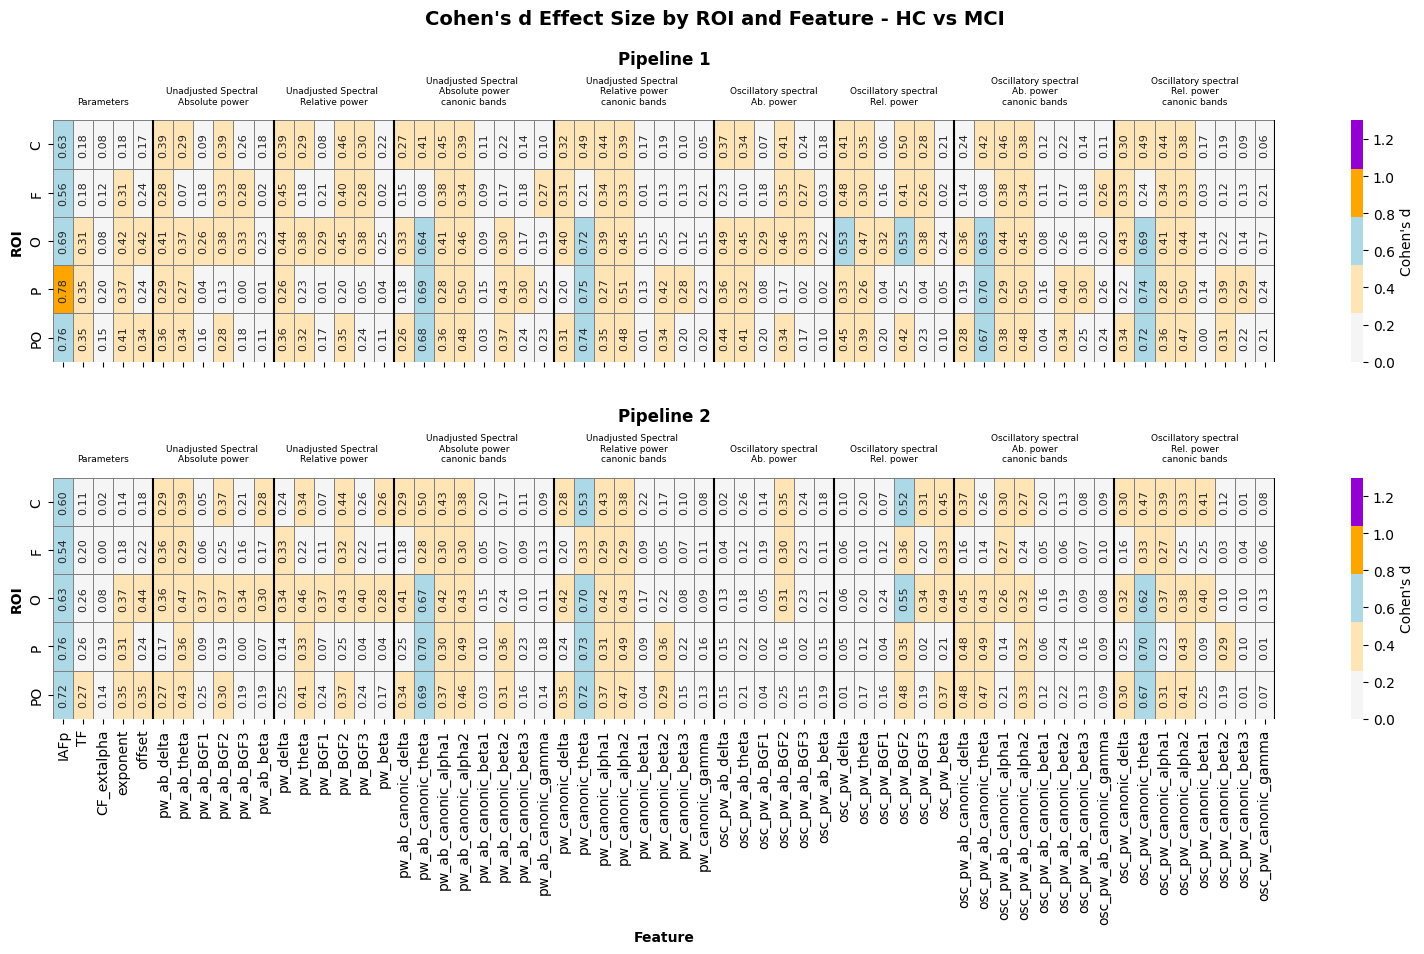

In [18]:
fig, axes = plt.subplots(nrows=2, figsize=(16, 10), sharex=True)

bounds = [0, 0.2, 0.5, 0.8, 1.3]
colors = ["whitesmoke", "moccasin", "lightblue", "orange", "darkviolet"]
cmap = sns.color_palette(colors)

category_boundaries = [
    'offset', 'pw_ab_beta', 'pw_beta', 'pw_ab_canonic_gamma',
    'pw_canonic_gamma', 'osc_pw_ab_beta', 'osc_pw_beta',
    'osc_pw_ab_canonic_gamma', 'osc_pw_canonic_gamma'
]

category_labels = [
    "Parameters",
    "Unadjusted Spectral \nAbsolute power",
    "Unadjusted Spectral \nRelative power",
    "Unadjusted Spectral \nAbsolute power\ncanonic bands",
    "Unadjusted Spectral \nRelative power\ncanonic bands",
    "Oscillatory spectral\nAb. power",
    "Oscillatory spectral\nRel. power",
    "Oscillatory spectral\nAb. power\ncanonic bands",
    "Oscillatory spectral\nRel. power\ncanonic bands"
]

for ax, data, title in zip(axes, [heatmap_data_p1, heatmap_data_p2], ["Pipeline 1", "Pipeline 2"]):
    sns.heatmap(
        data,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        annot_kws={"size": 8, "rotation": 90},
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={'label': "Cohen's d"},
        vmin=0,
        vmax=bounds[-1],
        ax=ax
    )
    xticks = data.columns.tolist()
    for boundary in category_boundaries:
        if boundary in xticks:
            idx = xticks.index(boundary) + 1
            ax.axvline(idx, color='black', linewidth=1.5)
    ax.set_title(title, fontsize=12, fontweight='bold', y=1.2)
    ax.set_ylabel("ROI", fontsize=10, fontweight='bold')
    ax.set_xlabel("")

axes[1].set_xlabel("Feature", fontsize=10, fontweight='bold')
axes[1].tick_params(axis='x', labelrotation=90)

# Añadir etiquetas de categoría arriba del primer heatmap
x_positions = []
xticks = heatmap_data_p1.columns.tolist()
previous_idx = 0
for boundary in category_boundaries:
    if boundary in xticks:
        current_idx = xticks.index(boundary)
        center = (previous_idx + current_idx) / 2
        x_positions.append(center)
        previous_idx = current_idx + 1
final_center = (previous_idx + len(xticks) - 1) / 2
x_positions.append(final_center)

for xpos, label in zip(x_positions, category_labels):
    axes[0].text(xpos+0.5, -0.3, label, ha='center', va='bottom', fontsize=6.5)
    axes[1].text(xpos+0.5, -0.3, label, ha='center', va='bottom', fontsize=6.5)

plt.suptitle("Cohen's d Effect Size by ROI and Feature - HC vs MCI",
             fontsize=14, fontweight='bold', y=0.95, x =0.45)
plt.tight_layout(rect=[0, 0, 1, 0.98])

# Guardar
plt.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\Cohen_d_comparison_P1_P2.pdf',
            dpi=600, format='pdf', bbox_inches='tight', transparent=True)
plt.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\Cohen_d_comparison_P1_P2.svg',
            dpi=600, format='svg', bbox_inches='tight', transparent=True)
plt.show()


In [19]:
df_cohen_p1 = prepare_df_cohen(IAF_FOOOF_age_p1,'AD')
df_cohen_p2 = prepare_df_cohen(IAF_FOOOF_age_p2,'AD')


def format_df(df_cohen):
    df = df_cohen[df_cohen['BaseFeature'].isin(features)].copy()
    df['BaseFeature'] = pd.Categorical(df['BaseFeature'], categories=features, ordered=True)
    return df.pivot(index='ROI', columns='BaseFeature', values='Cohen_d')

heatmap_data_p1 = format_df(df_cohen_p1)
heatmap_data_p2 = format_df(df_cohen_p2)

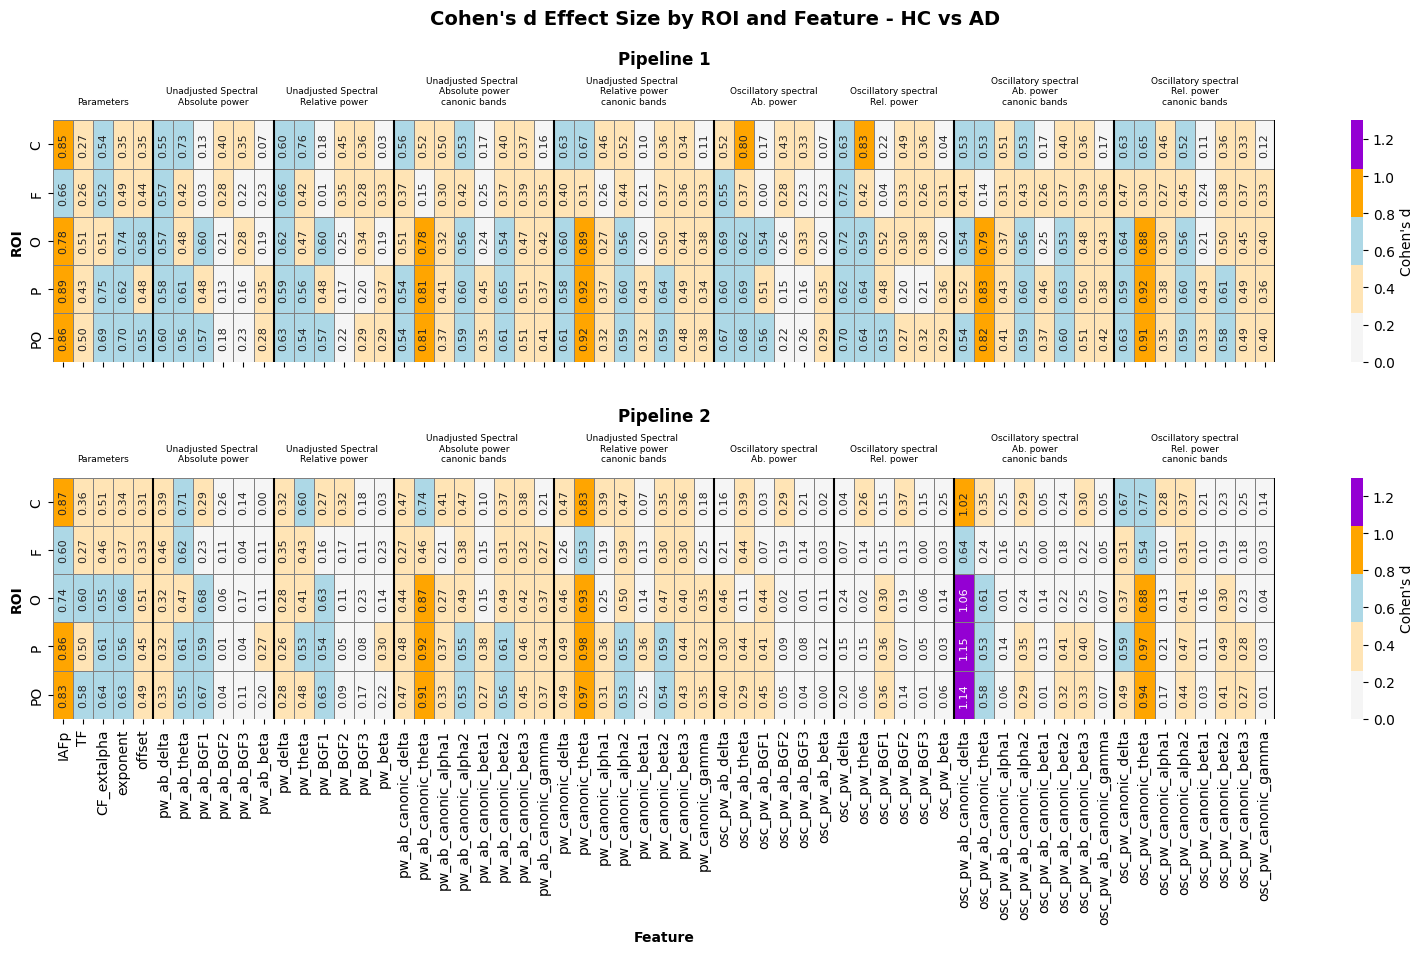

In [20]:
fig, axes = plt.subplots(nrows=2, figsize=(16, 10), sharex=True)

bounds = [0, 0.2, 0.5, 0.8, 1.3]
colors = ["whitesmoke", "moccasin", "lightblue", "orange", "darkviolet"]
cmap = sns.color_palette(colors)

category_boundaries = [
    'offset', 'pw_ab_beta', 'pw_beta', 'pw_ab_canonic_gamma',
    'pw_canonic_gamma', 'osc_pw_ab_beta', 'osc_pw_beta',
    'osc_pw_ab_canonic_gamma', 'osc_pw_canonic_gamma'
]

category_labels = [
    "Parameters",
    "Unadjusted Spectral \nAbsolute power",
    "Unadjusted Spectral \nRelative power",
    "Unadjusted Spectral \nAbsolute power\ncanonic bands",
    "Unadjusted Spectral \nRelative power\ncanonic bands",
    "Oscillatory spectral\nAb. power",
    "Oscillatory spectral\nRel. power",
    "Oscillatory spectral\nAb. power\ncanonic bands",
    "Oscillatory spectral\nRel. power\ncanonic bands"
]

for ax, data, title in zip(axes, [heatmap_data_p1, heatmap_data_p2], ["Pipeline 1", "Pipeline 2"]):
    sns.heatmap(
        data,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        annot_kws={"size": 8, "rotation": 90},
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={'label': "Cohen's d"},
        vmin=0,
        vmax=bounds[-1],
        ax=ax
    )
    xticks = data.columns.tolist()
    for boundary in category_boundaries:
        if boundary in xticks:
            idx = xticks.index(boundary) + 1
            ax.axvline(idx, color='black', linewidth=1.5)
    ax.set_title(title, fontsize=12, fontweight='bold', y=1.2)
    ax.set_ylabel("ROI", fontsize=10, fontweight='bold')
    ax.set_xlabel("")

axes[1].set_xlabel("Feature", fontsize=10, fontweight='bold')
axes[1].tick_params(axis='x', labelrotation=90)

# Añadir etiquetas de categoría arriba del primer heatmap
x_positions = []
xticks = heatmap_data_p1.columns.tolist()
previous_idx = 0
for boundary in category_boundaries:
    if boundary in xticks:
        current_idx = xticks.index(boundary)
        center = (previous_idx + current_idx) / 2
        x_positions.append(center)
        previous_idx = current_idx + 1
final_center = (previous_idx + len(xticks) - 1) / 2
x_positions.append(final_center)

for xpos, label in zip(x_positions, category_labels):
    axes[0].text(xpos+0.5, -0.3, label, ha='center', va='bottom', fontsize=6.5)
    axes[1].text(xpos+0.5, -0.3, label, ha='center', va='bottom', fontsize=6.5)

plt.suptitle("Cohen's d Effect Size by ROI and Feature - HC vs AD",
             fontsize=14, fontweight='bold', y=0.95, x =0.45)
plt.tight_layout(rect=[0, 0, 1, 0.98])

# Guardar
plt.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\Cohend_AD_comparison_P1_P2.pdf',
            dpi=600, format='pdf', bbox_inches='tight', transparent=True)
plt.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\Cohend_AD_comparison_P1_P2.svg',
            dpi=600, format='svg', bbox_inches='tight', transparent=True)
plt.show()


In [21]:
df_cohen_p1 = prepare_df_cohen(IAF_FOOOF_age_p1,'PD')
df_cohen_p2 = prepare_df_cohen(IAF_FOOOF_age_p2,'PD')


def format_df(df_cohen):
    df = df_cohen[df_cohen['BaseFeature'].isin(features)].copy()
    df['BaseFeature'] = pd.Categorical(df['BaseFeature'], categories=features, ordered=True)
    return df.pivot(index='ROI', columns='BaseFeature', values='Cohen_d')

heatmap_data_p1 = format_df(df_cohen_p1)
heatmap_data_p2 = format_df(df_cohen_p2)

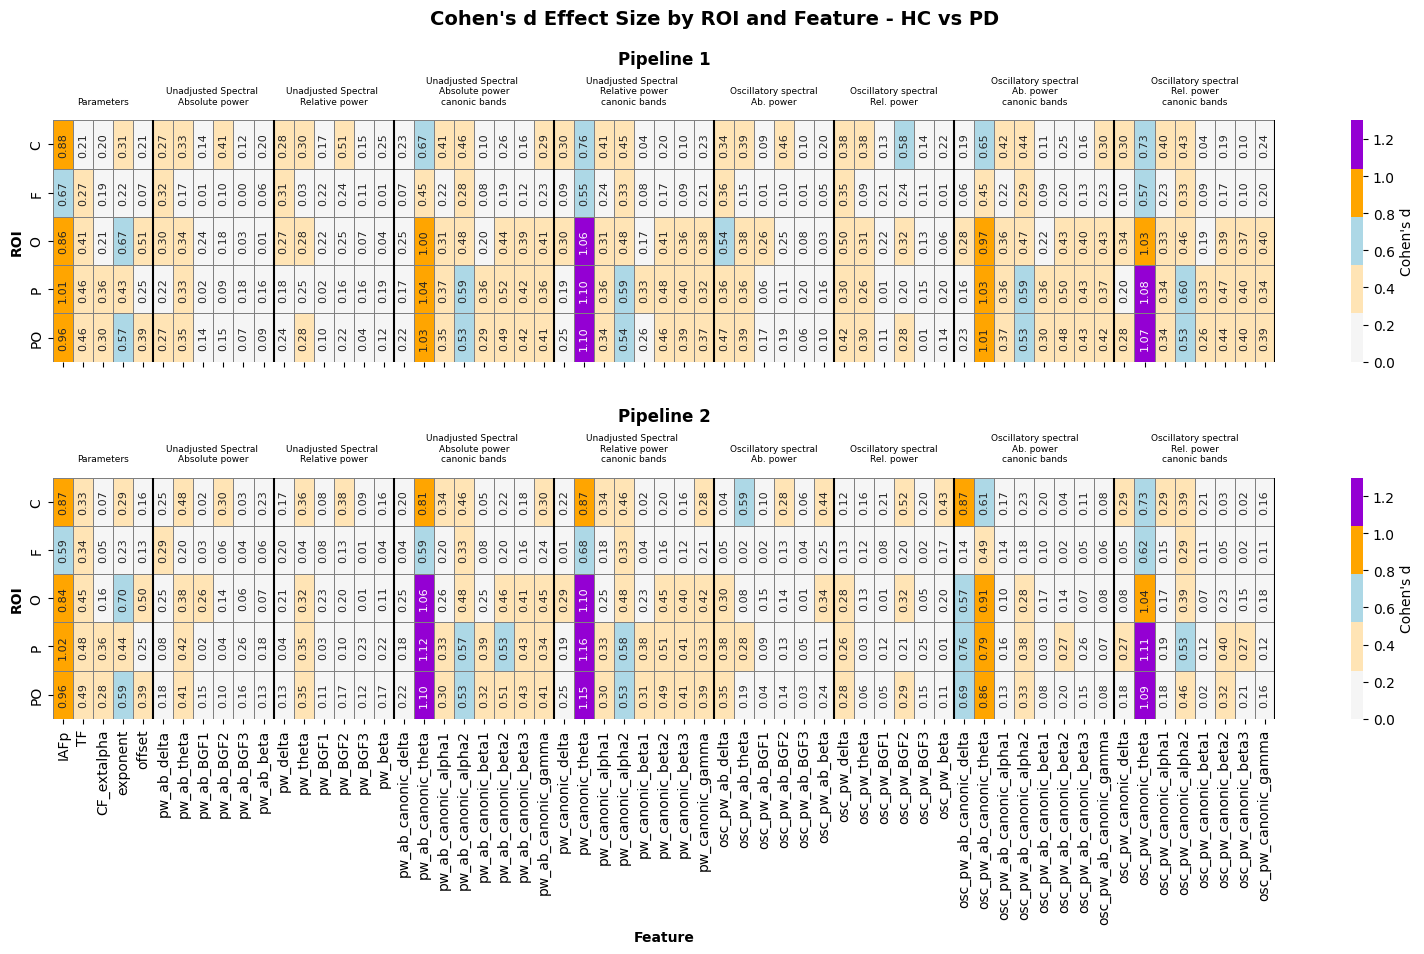

In [22]:
fig, axes = plt.subplots(nrows=2, figsize=(16, 10), sharex=True)

bounds = [0, 0.2, 0.5, 0.8, 1.3]
colors = ["whitesmoke", "moccasin", "lightblue", "orange", "darkviolet"]
cmap = sns.color_palette(colors)

category_boundaries = [
    'offset', 'pw_ab_beta', 'pw_beta', 'pw_ab_canonic_gamma',
    'pw_canonic_gamma', 'osc_pw_ab_beta', 'osc_pw_beta',
    'osc_pw_ab_canonic_gamma', 'osc_pw_canonic_gamma'
]

category_labels = [
    "Parameters",
    "Unadjusted Spectral \nAbsolute power",
    "Unadjusted Spectral \nRelative power",
    "Unadjusted Spectral \nAbsolute power\ncanonic bands",
    "Unadjusted Spectral \nRelative power\ncanonic bands",
    "Oscillatory spectral\nAb. power",
    "Oscillatory spectral\nRel. power",
    "Oscillatory spectral\nAb. power\ncanonic bands",
    "Oscillatory spectral\nRel. power\ncanonic bands"
]

for ax, data, title in zip(axes, [heatmap_data_p1, heatmap_data_p2], ["Pipeline 1", "Pipeline 2"]):
    sns.heatmap(
        data,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        annot_kws={"size": 8, "rotation": 90},
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={'label': "Cohen's d"},
        vmin=0,
        vmax=bounds[-1],
        ax=ax
    )
    xticks = data.columns.tolist()
    for boundary in category_boundaries:
        if boundary in xticks:
            idx = xticks.index(boundary) + 1
            ax.axvline(idx, color='black', linewidth=1.5)
    ax.set_title(title, fontsize=12, fontweight='bold', y=1.2)
    ax.set_ylabel("ROI", fontsize=10, fontweight='bold')
    ax.set_xlabel("")

axes[1].set_xlabel("Feature", fontsize=10, fontweight='bold')
axes[1].tick_params(axis='x', labelrotation=90)

# Añadir etiquetas de categoría arriba del primer heatmap
x_positions = []
xticks = heatmap_data_p1.columns.tolist()
previous_idx = 0
for boundary in category_boundaries:
    if boundary in xticks:
        current_idx = xticks.index(boundary)
        center = (previous_idx + current_idx) / 2
        x_positions.append(center)
        previous_idx = current_idx + 1
final_center = (previous_idx + len(xticks) - 1) / 2
x_positions.append(final_center)

for xpos, label in zip(x_positions, category_labels):
    axes[0].text(xpos+0.5, -0.3, label, ha='center', va='bottom', fontsize=6.5)
    axes[1].text(xpos+0.5, -0.3, label, ha='center', va='bottom', fontsize=6.5)

plt.suptitle("Cohen's d Effect Size by ROI and Feature - HC vs PD",
             fontsize=14, fontweight='bold', y=0.95, x =0.45)
plt.tight_layout(rect=[0, 0, 1, 0.98])

# Guardar
plt.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\Cohend_PD_comparison_P1_P2.pdf',
            dpi=600, format='pdf', bbox_inches='tight', transparent=True)
plt.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\Cohend_PD_comparison_P1_P2.svg',
            dpi=600, format='svg', bbox_inches='tight', transparent=True)
plt.show()


In [23]:
df_cohen_p1 = prepare_df_cohen(IAF_FOOOF_age_p1,'VD')
df_cohen_p2 = prepare_df_cohen(IAF_FOOOF_age_p2,'VD')


def format_df(df_cohen):
    df = df_cohen[df_cohen['BaseFeature'].isin(features)].copy()
    df['BaseFeature'] = pd.Categorical(df['BaseFeature'], categories=features, ordered=True)
    return df.pivot(index='ROI', columns='BaseFeature', values='Cohen_d')

heatmap_data_p1 = format_df(df_cohen_p1)
heatmap_data_p2 = format_df(df_cohen_p2)

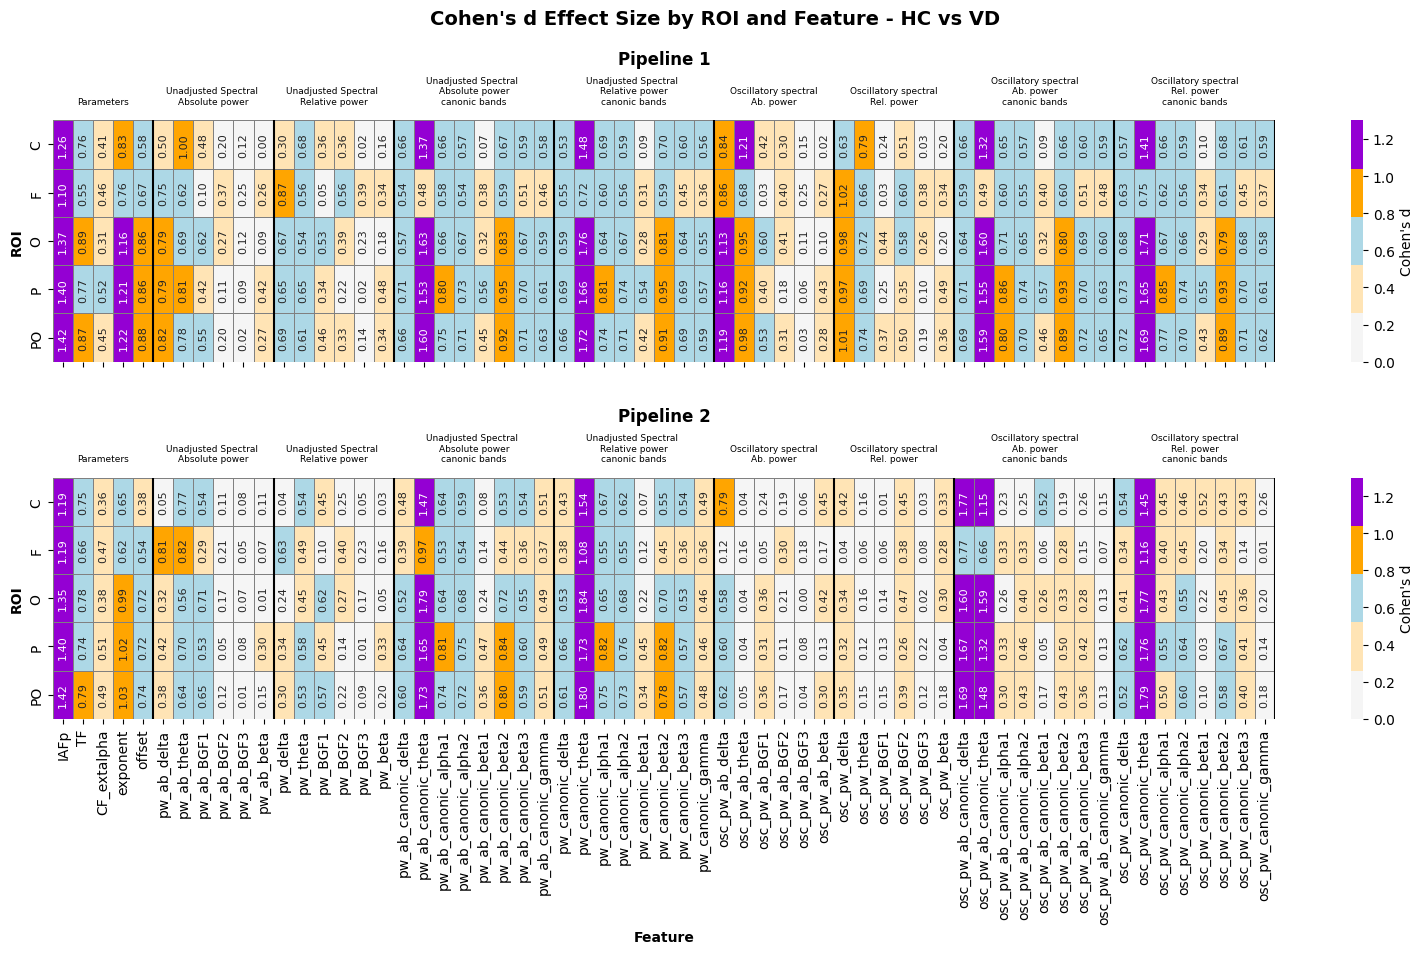

In [24]:
fig, axes = plt.subplots(nrows=2, figsize=(16, 10), sharex=True)


bounds = [0, 0.2, 0.5, 0.8, 1.3]
colors = ["whitesmoke", "moccasin", "lightblue", "orange", "darkviolet"]
cmap = sns.color_palette(colors)

category_boundaries = [
    'offset', 'pw_ab_beta', 'pw_beta', 'pw_ab_canonic_gamma',
    'pw_canonic_gamma', 'osc_pw_ab_beta', 'osc_pw_beta',
    'osc_pw_ab_canonic_gamma', 'osc_pw_canonic_gamma'
]

category_labels = [
    "Parameters",
    "Unadjusted Spectral \nAbsolute power",
    "Unadjusted Spectral \nRelative power",
    "Unadjusted Spectral \nAbsolute power\ncanonic bands",
    "Unadjusted Spectral \nRelative power\ncanonic bands",
    "Oscillatory spectral\nAb. power",
    "Oscillatory spectral\nRel. power",
    "Oscillatory spectral\nAb. power\ncanonic bands",
    "Oscillatory spectral\nRel. power\ncanonic bands"
]

for ax, data, title in zip(axes, [heatmap_data_p1, heatmap_data_p2], ["Pipeline 1", "Pipeline 2"]):
    sns.heatmap(
        data,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        annot_kws={"size": 8, "rotation": 90},
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={'label': "Cohen's d"},
        vmin=0,
        vmax=bounds[-1],
        ax=ax
    )
    xticks = data.columns.tolist()
    for boundary in category_boundaries:
        if boundary in xticks:
            idx = xticks.index(boundary) + 1
            ax.axvline(idx, color='black', linewidth=1.5)
    ax.set_title(title, fontsize=12, fontweight='bold', y=1.2)
    ax.set_ylabel("ROI", fontsize=10, fontweight='bold')
    ax.set_xlabel("")

axes[1].set_xlabel("Feature", fontsize=10, fontweight='bold')
axes[1].tick_params(axis='x', labelrotation=90)

# Añadir etiquetas de categoría arriba del primer heatmap
x_positions = []
xticks = heatmap_data_p1.columns.tolist()
previous_idx = 0
for boundary in category_boundaries:
    if boundary in xticks:
        current_idx = xticks.index(boundary)
        center = (previous_idx + current_idx) / 2
        x_positions.append(center)
        previous_idx = current_idx + 1
final_center = (previous_idx + len(xticks) - 1) / 2
x_positions.append(final_center)

for xpos, label in zip(x_positions, category_labels):
    axes[0].text(xpos+0.5, -0.3, label, ha='center', va='bottom', fontsize=6.5)
    axes[1].text(xpos+0.5, -0.3, label, ha='center', va='bottom', fontsize=6.5)

plt.suptitle("Cohen's d Effect Size by ROI and Feature - HC vs VD",
             fontsize=14, fontweight='bold', y=0.95, x =0.45)
plt.tight_layout(rect=[0, 0, 1, 0.98])

# Guardar
plt.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\Cohend_VD_comparison_P1_P2.pdf',
            dpi=600, format='pdf', bbox_inches='tight', transparent=True)
plt.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\Cohend_VD_comparison_P1_P2.svg',
            dpi=600, format='svg', bbox_inches='tight', transparent=True)
plt.show()


In [25]:
df_cohen_p1 = prepare_df_cohen(IAF_FOOOF_age_p1,'ACr')
df_cohen_p2 = prepare_df_cohen(IAF_FOOOF_age_p2,'ACr')


def format_df(df_cohen):
    df = df_cohen[df_cohen['BaseFeature'].isin(features)].copy()
    df['BaseFeature'] = pd.Categorical(df['BaseFeature'], categories=features, ordered=True)
    return df.pivot(index='ROI', columns='BaseFeature', values='Cohen_d')

heatmap_data_p1 = format_df(df_cohen_p1)
heatmap_data_p2 = format_df(df_cohen_p2)

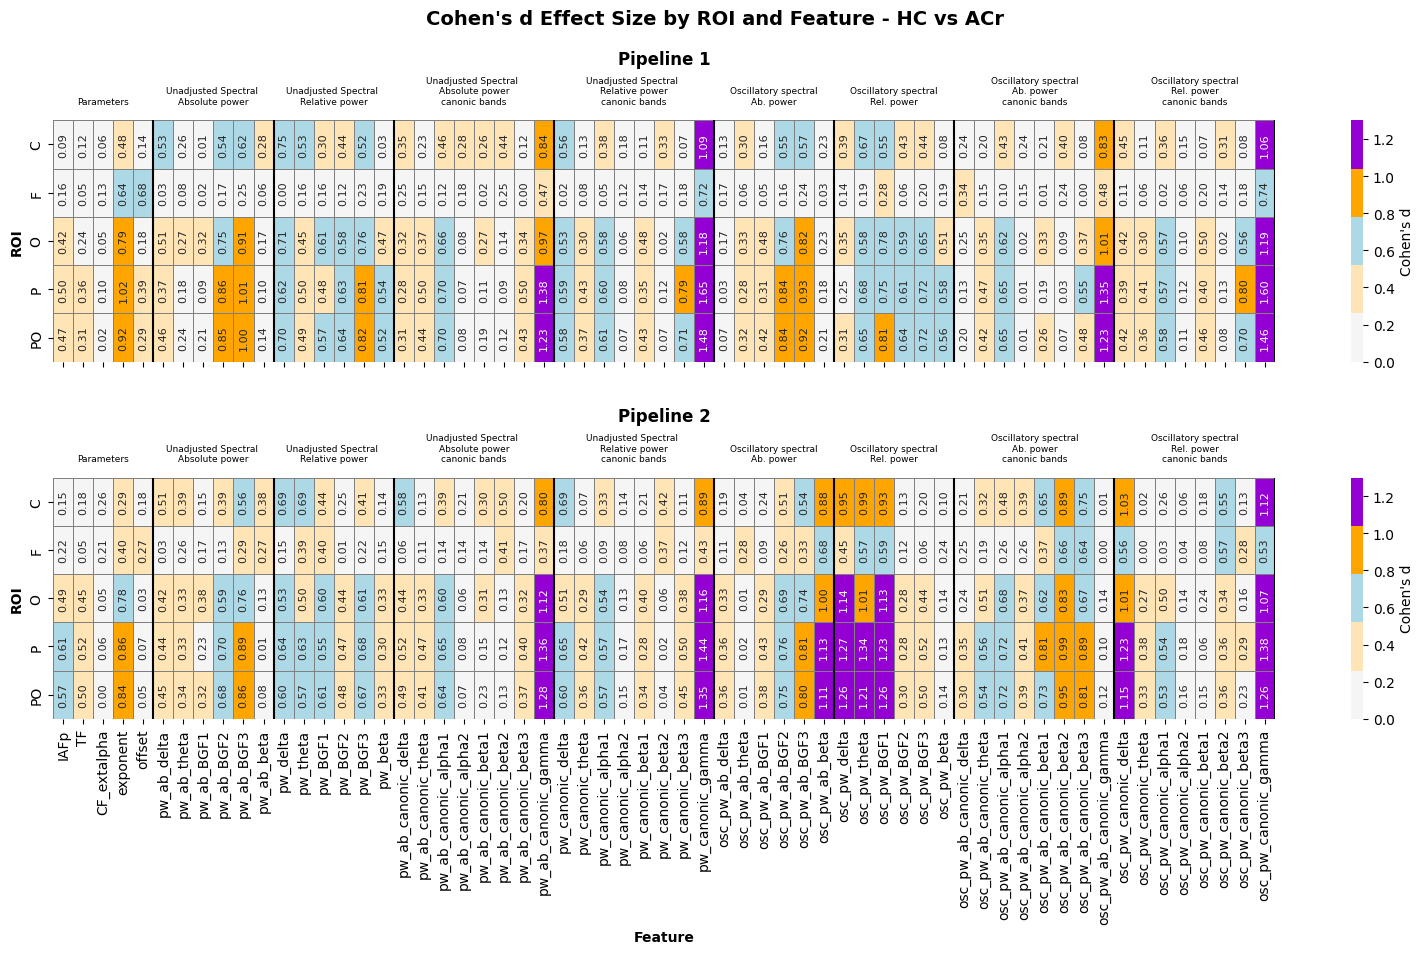

In [26]:
fig, axes = plt.subplots(nrows=2, figsize=(16, 10), sharex=True)

bounds = [0, 0.2, 0.5, 0.8, 1.3]
colors = ["whitesmoke", "moccasin", "lightblue", "orange", "darkviolet"]
cmap = sns.color_palette(colors)

category_boundaries = [
    'offset', 'pw_ab_beta', 'pw_beta', 'pw_ab_canonic_gamma',
    'pw_canonic_gamma', 'osc_pw_ab_beta', 'osc_pw_beta',
    'osc_pw_ab_canonic_gamma', 'osc_pw_canonic_gamma'
]

category_labels = [
    "Parameters",
    "Unadjusted Spectral \nAbsolute power",
    "Unadjusted Spectral \nRelative power",
    "Unadjusted Spectral \nAbsolute power\ncanonic bands",
    "Unadjusted Spectral \nRelative power\ncanonic bands",
    "Oscillatory spectral\nAb. power",
    "Oscillatory spectral\nRel. power",
    "Oscillatory spectral\nAb. power\ncanonic bands",
    "Oscillatory spectral\nRel. power\ncanonic bands"
]

for ax, data, title in zip(axes, [heatmap_data_p1, heatmap_data_p2], ["Pipeline 1", "Pipeline 2"]):
    sns.heatmap(
        data,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        annot_kws={"size": 8, "rotation": 90},
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={'label': "Cohen's d"},
        vmin=0,
        vmax=bounds[-1],
        ax=ax
    )
    xticks = data.columns.tolist()
    for boundary in category_boundaries:
        if boundary in xticks:
            idx = xticks.index(boundary) + 1
            ax.axvline(idx, color='black', linewidth=1.5)
    ax.set_title(title, fontsize=12, fontweight='bold', y=1.2)
    ax.set_ylabel("ROI", fontsize=10, fontweight='bold')
    ax.set_xlabel("")

axes[1].set_xlabel("Feature", fontsize=10, fontweight='bold')
axes[1].tick_params(axis='x', labelrotation=90)

# Añadir etiquetas de categoría arriba del primer heatmap
x_positions = []
xticks = heatmap_data_p1.columns.tolist()
previous_idx = 0
for boundary in category_boundaries:
    if boundary in xticks:
        current_idx = xticks.index(boundary)
        center = (previous_idx + current_idx) / 2
        x_positions.append(center)
        previous_idx = current_idx + 1
final_center = (previous_idx + len(xticks) - 1) / 2
x_positions.append(final_center)

for xpos, label in zip(x_positions, category_labels):
    axes[0].text(xpos+0.5, -0.3, label, ha='center', va='bottom', fontsize=6.5)
    axes[1].text(xpos+0.5, -0.3, label, ha='center', va='bottom', fontsize=6.5)

plt.suptitle("Cohen's d Effect Size by ROI and Feature - HC vs ACr",
             fontsize=14, fontweight='bold', y=0.95, x =0.45)
plt.tight_layout(rect=[0, 0, 1, 0.98])

# Guardar
plt.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\Cohend_ACr_comparison_P1_P2.pdf',
            dpi=600, format='pdf', bbox_inches='tight', transparent=True)
plt.savefig(r'D:\MulticentersEEG\graphs_thesis_LMZS\Cohend_ACr_comparison_P1_P2.svg',
            dpi=600, format='svg', bbox_inches='tight', transparent=True)
plt.show()
